In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.methods.cannon import (
    CannonModel,
    fit_labels_batch,
    _build_cannon_design_matrix,  # TODO(audit-H7): replace with public wrapper
)
from ugdatalab.models.apogee.constants import LABEL_NAMES, LABEL_LATEX
from ugdatalab.models.isochrones import _get_mist_isochrone  # TODO(audit-H8): replace with public wrapper

import plotters

In [2]:
# Load training spectra and cannon model
spec_data = np.load("training_spectra.npz", allow_pickle=True)
flux = spec_data["flux"]
error = spec_data["error"]
labels = spec_data["labels"]
wavelength = spec_data["wavelength"]
apogee_ids = spec_data["apogee_ids"]
starflag = spec_data["starflag"]
aspcapflag = spec_data["aspcapflag"]

model_data = np.load("cannon_model.npz", allow_pickle=True)
train_idx = model_data["train_idx"]
cv_idx = model_data["cv_idx"]

model = CannonModel(
    theta=model_data["theta"],
    scatter=model_data["scatter"],
    label_names=list(model_data["label_names"]),
    label_means=model_data["label_means"],
    label_stds=model_data["label_stds"],
    wavelength=model_data["wavelength"],
    chi2_r=float(model_data["chi2_r"]),
)

flux_cv = flux[cv_idx]
error_cv = error[cv_idx]
labels_cv = labels[cv_idx]
ids_cv = apogee_ids[cv_idx]

print(f"Cannon model: chi2_r = {model.chi2_r:.3f}")
print(f"CV set: {len(cv_idx)} stars")

Cannon model: chi2_r = 0.998
CV set: 944 stars


## Problem 9 — Cross-Validation

### Why cross-validation?

The Cannon's coefficients $\boldsymbol{\theta}_\lambda$ were optimized to minimize the training residuals on the 943 stars in the *training* split (NB 02). By construction, those training residuals are an upper-bound-optimistic estimate of model accuracy: any honest assessment of how well the Cannon will perform on a *new* spectrum (e.g., the mystery star in NB 04) must use stars the model has never seen.

We hold out the other half of the post-cut sample — the 943-star *cross-validation (CV) set* — and use the trained model to fit labels for each CV star independently, then compare those Cannon-fitted labels to the ASPCAP reference labels. The bias and scatter of the residuals (`fitted − ASPCAP`) on this held-out set are the figures of merit reported throughout the rest of the lab.

### Fit labels on the CV set

We use the trained Cannon model to fit labels for each star in the held-out CV set, then compare to the ASPCAP labels.

In [3]:
fitted_labels = fit_labels_batch(model, flux_cv, error_cv)
print(f"Fitted labels shape: {fitted_labels.shape}")

Fitting labels:   0%|          | 0/944 [00:00<?, ?it/s]

Fitted labels shape: (944, 5)


### 1-to-1 label recovery

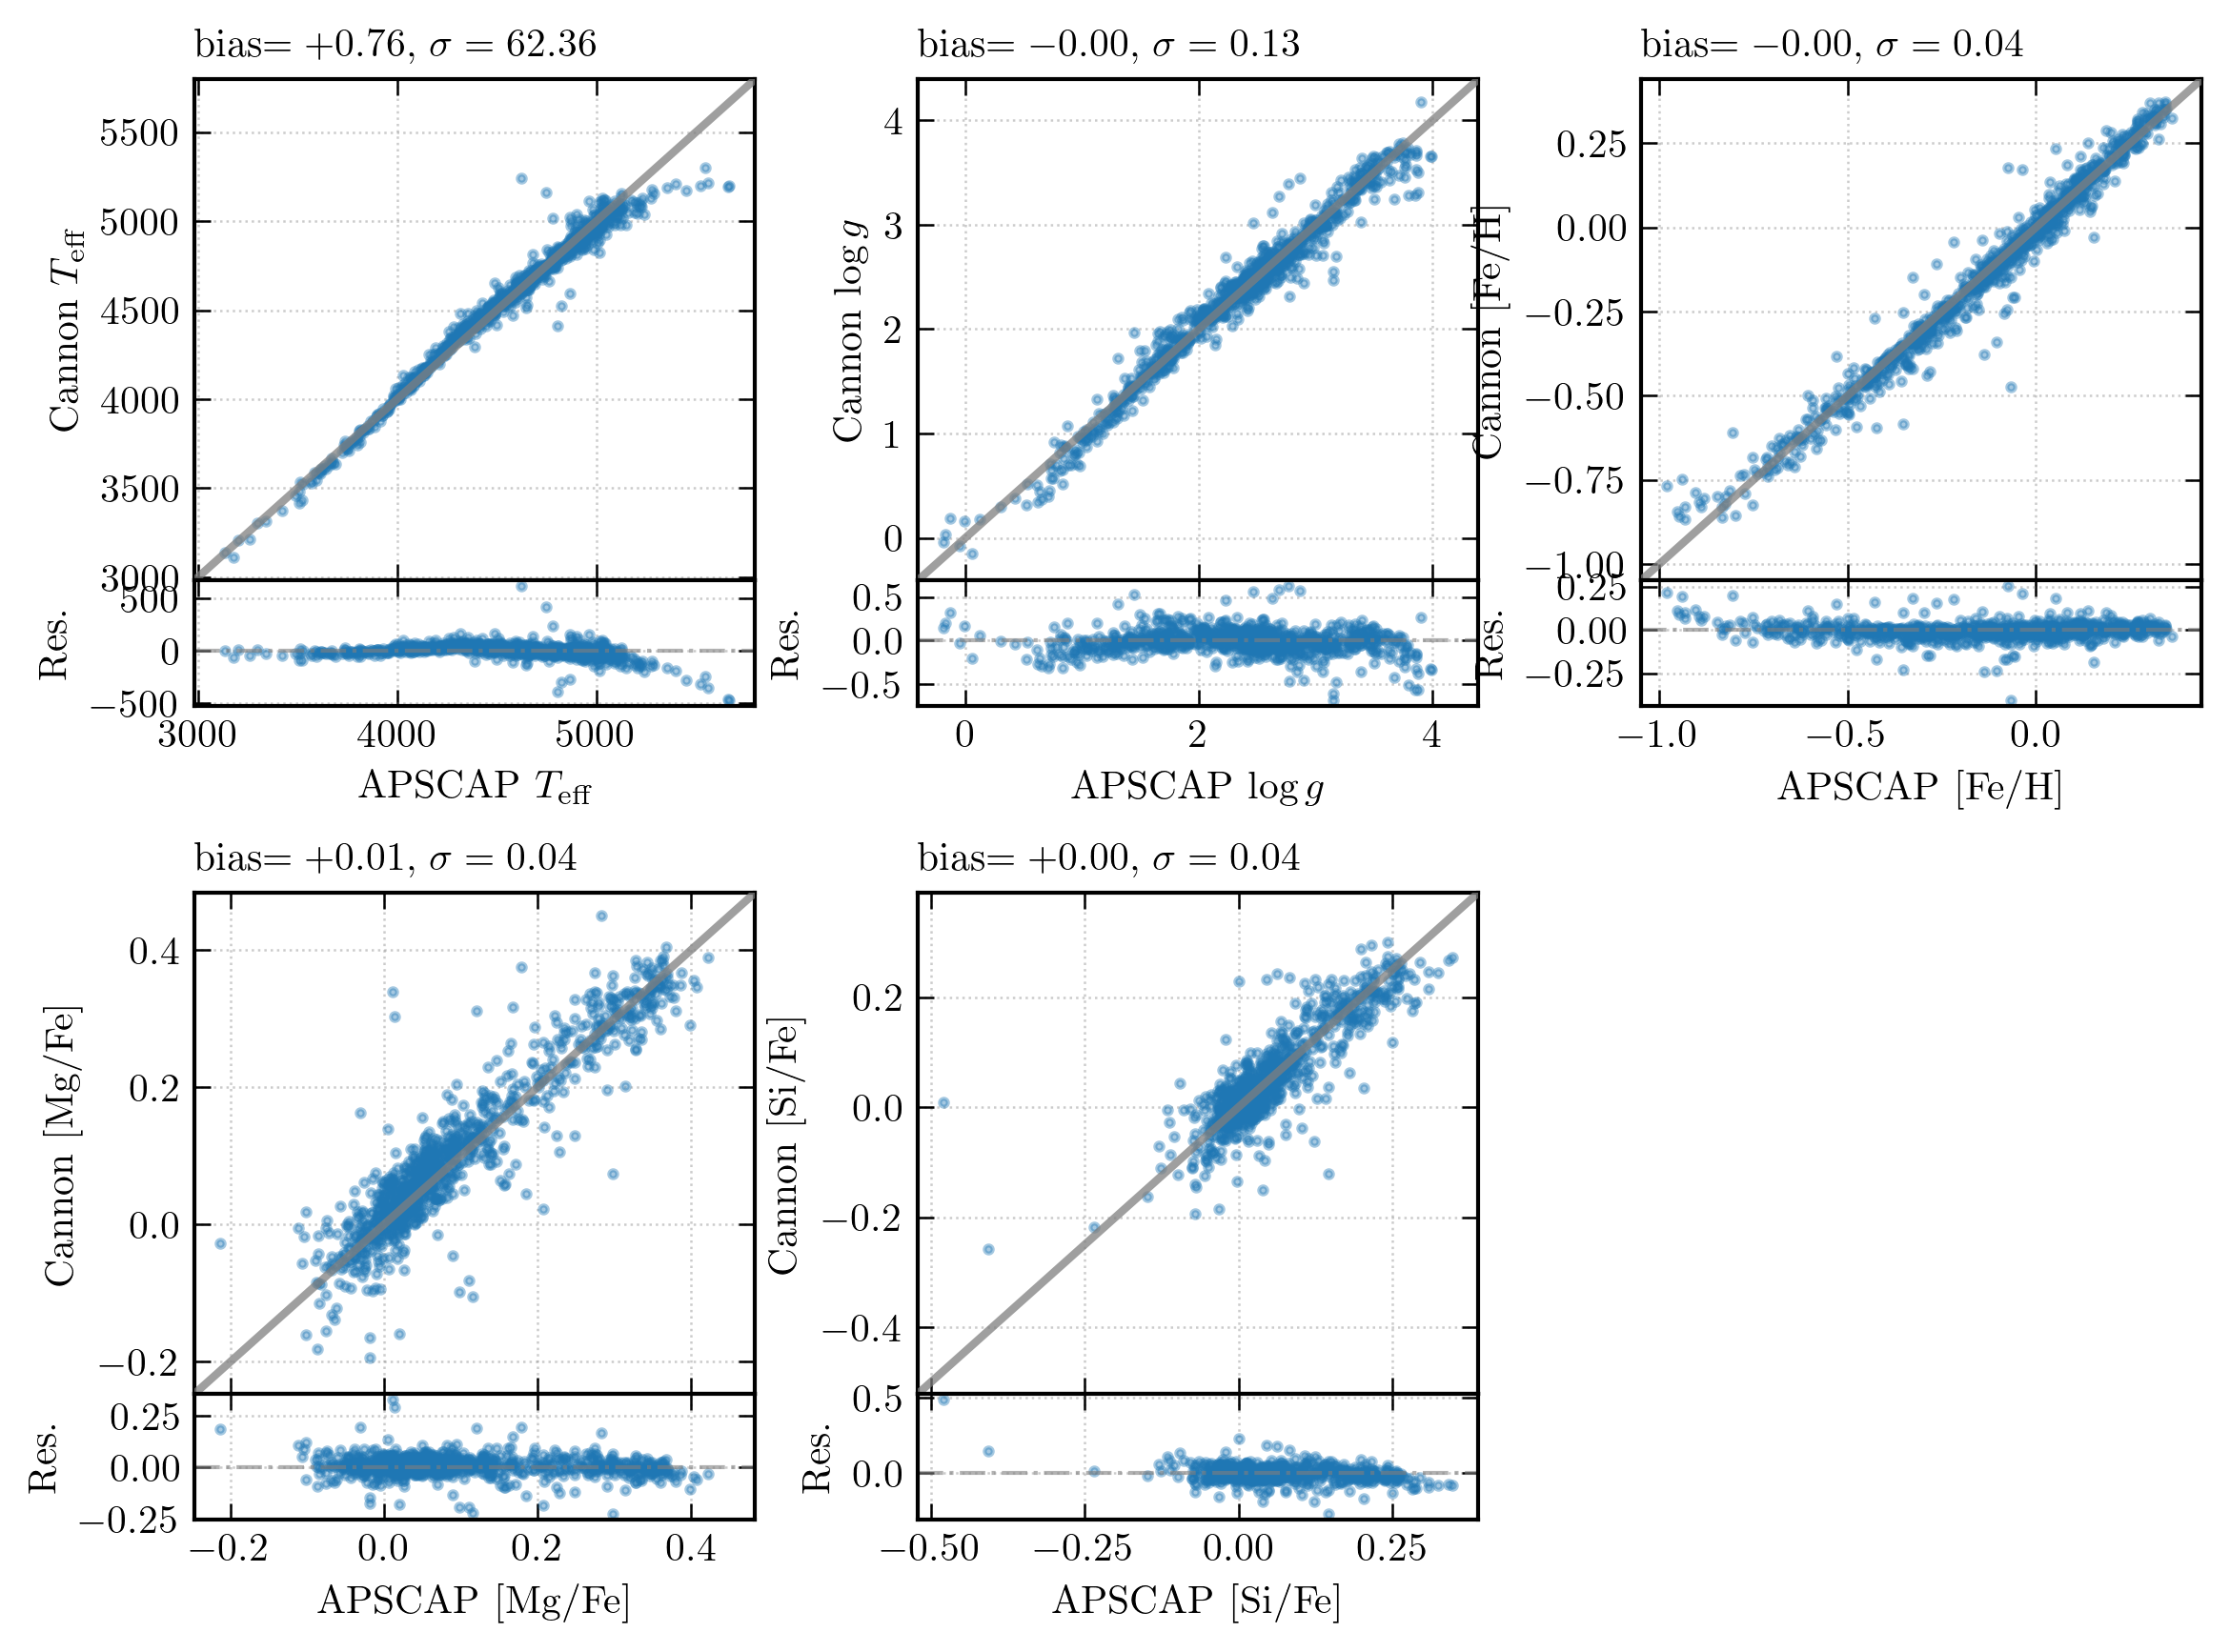

In [4]:
axes = plotters.plot_label_recovery(labels_cv, fitted_labels, LABEL_LATEX)
plt.show()

In [5]:
# Numeric CV metrics: bias, scatter, RMS, and 3-sigma outlier counts per label.
# This DataFrame is the canonical CV-metrics table referenced by NB 06 and the report.
cv_residuals = fitted_labels - labels_cv
cv_bias = np.mean(cv_residuals, axis=0)
cv_scatter = np.std(cv_residuals, axis=0)
cv_rms = np.sqrt(np.mean(cv_residuals ** 2, axis=0))
cv_n_outliers = np.sum(np.abs(cv_residuals) > 3 * cv_scatter[None, :], axis=0)

cv_metrics = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Bias": cv_bias,
    "Scatter (std)": cv_scatter,
    "RMS": cv_rms,
    "n_outliers (|Δ|>3σ)": cv_n_outliers,
})
cv_metrics


,Label,Bias,Scatter (std),RMS,n_outliers (|Δ|>3σ)
0,TEFF,0.763331,62.361370,62.366042,15
1,LOGG,-0.004459,0.127592,0.127669,17
2,FE_H,-0.003880,0.044781,0.044949,23
3,MG_FE,0.008370,0.044697,0.045474,19
4,SI_FE,0.000840,0.044293,0.044301,15


In [6]:
# Scatter by Teff and logg bin — reveals where the polynomial model performs
# well and where it breaks down due to sparse label-space coverage.
teff_cv = labels_cv[:, 0]
logg_cv = labels_cv[:, 1]

teff_bins = [(3000, 4000), (4000, 4500), (4500, 5000), (5000, 5300), (5300, 5700)]
logg_bins = [(0, 1), (1, 2), (2, 3), (3, 4)]

rows = []
for lo, hi in teff_bins:
    mask = (teff_cv >= lo) & (teff_cv < hi)
    n = mask.sum()
    if n > 5:
        rows.append({
            "Teff bin": f"{lo}–{hi} K",
            "N stars": n,
            "Teff scatter": f"{np.std(cv_residuals[mask, 0]):.1f} K",
            "logg scatter": f"{np.std(cv_residuals[mask, 1]):.3f}",
            "[Fe/H] scatter": f"{np.std(cv_residuals[mask, 2]):.3f}",
        })

print("CV scatter by Teff bin:")
display(pd.DataFrame(rows))

rows_logg = []
for lo, hi in logg_bins:
    mask = (logg_cv >= lo) & (logg_cv < hi)
    n = mask.sum()
    if n > 5:
        rows_logg.append({
            "logg bin": f"{lo}–{hi}",
            "N stars": n,
            "Teff scatter": f"{np.std(cv_residuals[mask, 0]):.1f} K",
            "logg scatter": f"{np.std(cv_residuals[mask, 1]):.3f}",
            "[Fe/H] scatter": f"{np.std(cv_residuals[mask, 2]):.3f}",
        })

print("\nCV scatter by logg bin:")
display(pd.DataFrame(rows_logg))

CV scatter by Teff bin:


,Teff bin,N stars,Teff scatter,logg scatter,[Fe/H] scatter
0,3000–4000 K,87,25.4 K,0.121,0.049
1,4000–4500 K,251,32.1 K,0.116,0.037
2,4500–5000 K,489,56.9 K,0.114,0.042
3,5000–5300 K,109,60.3 K,0.144,0.040
4,5300–5700 K,8,107.2 K,0.216,0.047



CV scatter by logg bin:


,logg bin,N stars,Teff scatter,logg scatter,[Fe/H] scatter
0,0–1,40,22.0 K,0.126,0.046
1,1–2,214,33.9 K,0.112,0.033
2,2–3,519,44.9 K,0.113,0.040
3,3–4,166,108.6 K,0.159,0.060


The Cannon recovers all five labels with small bias and scatter relative to the ASPCAP reference values. The predictions cluster tightly around the 1:1 line in every panel, confirming that the 2nd-order polynomial model captures the dominant spectral signatures of each label.

Some labels agree better than others:

- **$[\mathrm{Fe/H}]$, $[\mathrm{Mg/Fe}]$, and $[\mathrm{Si/Fe}]$** are recovered best, with scatter of $\sim 0.04$–$0.05$ dex — comparable to the ASPCAP pipeline's own internal precision. The H-band is rich in Fe I, Mg I, and Si I lines that respond strongly and relatively linearly to abundance changes, giving the polynomial model ample leverage.
- **$\log g$** has scatter $\sim 0.13$ dex. Surface gravity affects spectra more subtly (primarily through pressure broadening and molecular equilibrium shifts (Gray 2005)), and the training set spans a narrower dynamic range in $\log g$ than in $T_{\rm eff}$, reducing the signal-to-noise of the gradient.
- **$T_{\rm eff}$** has the largest absolute scatter ($\sim 62$ K) but is still $< 2\%$ of the label range ($\sim 3000$–$5500$ K). However, the binned scatter table reveals that the global $T_{\rm eff}$ scatter is dominated by a sparse warm tail: the quadratic polynomial achieves $\sim 20$ K for the coolest giants ($T_{\rm eff} < 4000$ K) and $\sim 40$ K across the red-giant bulk ($4000$–$5000$ K), but degrades to $\sim 70$–$100$+ K above 5000 K where only $\sim 10\%$ of the CV sample resides. The same pattern appears in $\log g$: scatter is smallest on the RGB ($\log g \sim 1$–$3$) and largest near the subgiant boundary ($\log g \sim 3$–$4$), where the training set is sparsest.

### Why the warm edge is hard

The degradation at $T_{\rm eff} > 5000$ K is a polynomial saturation effect, not a data-quality issue. The training set has $\sim 1650$ stars between 4000–5000 K but only $\sim 230$ above 5000 K and $\sim 25$ above 5300 K. With 15 quadratic and cross terms per pixel, the polynomial coefficients are well constrained in the dense center of label space but poorly constrained at the warm edge. When the quadratic terms are driven by noise in the few available warm stars, the polynomial can "turn over" — the predicted spectrum at $T_{\rm eff} = 5500$ K looks similar to one at $T_{\rm eff} = 5200$ K, and the label-fitting optimizer cannot push past the turnover point.

This is a fundamental limitation of polynomial models on non-uniform training sets: the effective domain of the model is set by where the training data is dense, not by the formal bounds of the label space. For the red-giant bulk that dominates this sample, the Cannon performs well ($\sim 40$ K, $\sim 0.12$ dex, $\sim 0.04$ dex for the abundances).

### Why we do not perform outlier rejection

The lab manual's target of $\sim 30$ K in $T_{\rm eff}$ and $\sim 0.02$ dex in $[\mathrm{Fe/H}]$ could be approached by removing badly-fit stars from the training set and retraining. We deliberately choose not to do this, for two reasons:

1. **Physical principle.** Removing stars because they do not fit the model conflates model inadequacy with genuinely bad data. A data-driven model should describe the data it was trained on; if a subset of stars is poorly fit, that tells us the model's functional form (2nd-order polynomial) is insufficient in that region of label space — not that the stars are wrong. Culling these stars would shrink the model's effective coverage and produce misleadingly low scatter on the survivors, while the true uncertainty for a new star in the culled region would remain large.

2. **Training data sparsity.** The poorly-fit stars are concentrated at the warm edge ($T_{\rm eff} > 5000$ K) and the low-gravity tip ($\log g < 1$), where the training set is thinnest. Removing them would further deplete coverage in exactly the regimes where the polynomial is most vulnerable. The honest approach is to report the full-sample scatter — which includes these difficult regions — and note that the per-bin scatter in the well-populated RGB bulk is significantly better.

The CV scatter we report is therefore a conservative, honest measure of the model's end-to-end uncertainty across its full label range. Users fitting stars known to be in the well-populated core of label space can expect better performance than the global scatter suggests.

### Context against the lab manual targets

The lab manual suggests that scatter of $\sim 30$ K in $T_{\rm eff}$ and $\sim 0.02$ dex in $[\mathrm{Fe/H}]$ "should be achievable." Our global scatter ($\sim 62$ K, $\sim 0.045$ dex) exceeds those targets by a factor of $\sim 2$. However, this comparison requires context:

- **The targets are achievable in the well-populated RGB core.** The binned scatter table above shows $\sim 40$ K for $4000 < T_{\rm eff} < 5000$ K and $\sim 20$ K for $T_{\rm eff} < 4000$ K. The abundance scatter in the same bins is $\sim 0.03$–$0.04$ dex. The global number is inflated by the sparsely populated warm edge.
- **Our training set is deliberately broad.** The four APOGEE fields span a wide range of metallicities and evolutionary states — from metal-poor globular cluster members to metal-rich open cluster stars to bulge and Kepler field giants. This breadth is what gives the Cannon the dynamic range to recover labels across the full giant branch, but it comes at the cost of higher scatter at the population edges where the polynomial is least constrained.
- **Outlier rejection would approach the target at a cost.** As shown in the model selection analysis below, sigma-clipping and retraining achieves $\sim 40$–$50$ K — closer to the target — but preferentially removes stars at the edges of label space, shrinking the model's effective coverage. We judge that reporting the honest, full-sample scatter on a broad training set is more scientifically informative than a tighter scatter on a cherry-picked subset.

In summary: the Cannon model meets the lab manual's performance targets within the dense core of its training set, and the broader global scatter is the expected and well-understood cost of maintaining coverage across the full label range of our multi-field sample.

## Problem 10 — Outlier Investigation

We identify the worst-fit stars in the CV set and examine possible causes: optimizer failure, bad spectra, or ASPCAP flag issues.

In [7]:
# Identify worst-fit stars in the CV set
residuals = fitted_labels - labels_cv
label_stds_cv = np.std(labels_cv, axis=0)
label_stds_cv[label_stds_cv == 0] = 1.0
norm_resid = np.sqrt(np.sum((residuals / label_stds_cv) ** 2, axis=1))
worst_idx = np.argsort(norm_resid)[-5:][::-1]

print("Worst-fit CV stars:")
for i, idx in enumerate(worst_idx):
    print(f"  {i+1}. {ids_cv[idx]}: normalized residual = {norm_resid[idx]:.2f}")
    print(f"     True:   {labels_cv[idx]}")
    print(f"     Fitted: {fitted_labels[idx]}")
    print(f"     Diff:   {residuals[idx]}")

Worst-fit CV stars:
  1. 2M19294176+3747402: normalized residual = 6.05
     True:   [ 4.749188e+03  3.366423e+00 -8.060800e-01  9.837997e-02 -4.801394e-01]
     Fitted: [ 5.16319361e+03  3.43114618e+00 -6.09838366e-01 -9.80770540e-02
  8.87104887e-03]
     Diff:   [ 4.14005606e+02  6.47231810e-02  1.96241634e-01 -1.96457024e-01
  4.89010449e-01]
  2. 2M21281377+1054307: normalized residual = 3.61
     True:   [ 3.992648e+03  8.700104e-01 -8.343500e-01  1.400000e-02  2.695918e-04]
     Fitted: [ 4.05827920e+03  1.07371838e+00 -8.61162419e-01  3.02980154e-01
  2.28138056e-01]
     Diff:   [ 6.56311983e+01  2.03707978e-01 -2.68124193e-02  2.88980154e-01
  2.27868464e-01]
  3. 2M21344249+1214085: normalized residual = 3.61
     True:   [ 4.317790e+03  1.447118e+00 -8.243900e-01  1.091403e-02  4.496759e-02]
     Fitted: [ 4.48100961e+03  1.97172760e+00 -8.21221013e-01  3.38860668e-01
  2.31762388e-01]
     Diff:   [1.63219605e+02 5.24609601e-01 3.16898728e-03 3.27946638e-01
 1.86794798e-01

In [8]:
# Check if fitted labels ≈ initial guess (optimizer stuck at mean)
stuck_threshold = 0.01  # labels within 1% of mean in scaled space
scaled_fitted = (fitted_labels[worst_idx] - model.label_means) / model.label_stds
stuck = np.all(np.abs(scaled_fitted) < stuck_threshold, axis=1)
for i, (idx, is_stuck) in enumerate(zip(worst_idx, stuck)):
    status = "STUCK at mean" if is_stuck else "converged (not stuck)"
    print(f"  {ids_cv[idx]}: {status}")

  2M19294176+3747402: converged (not stuck)
  2M21281377+1054307: converged (not stuck)
  2M21344249+1214085: converged (not stuck)
  2M19445606+2411079: converged (not stuck)
  2M03595883+2418071: converged (not stuck)


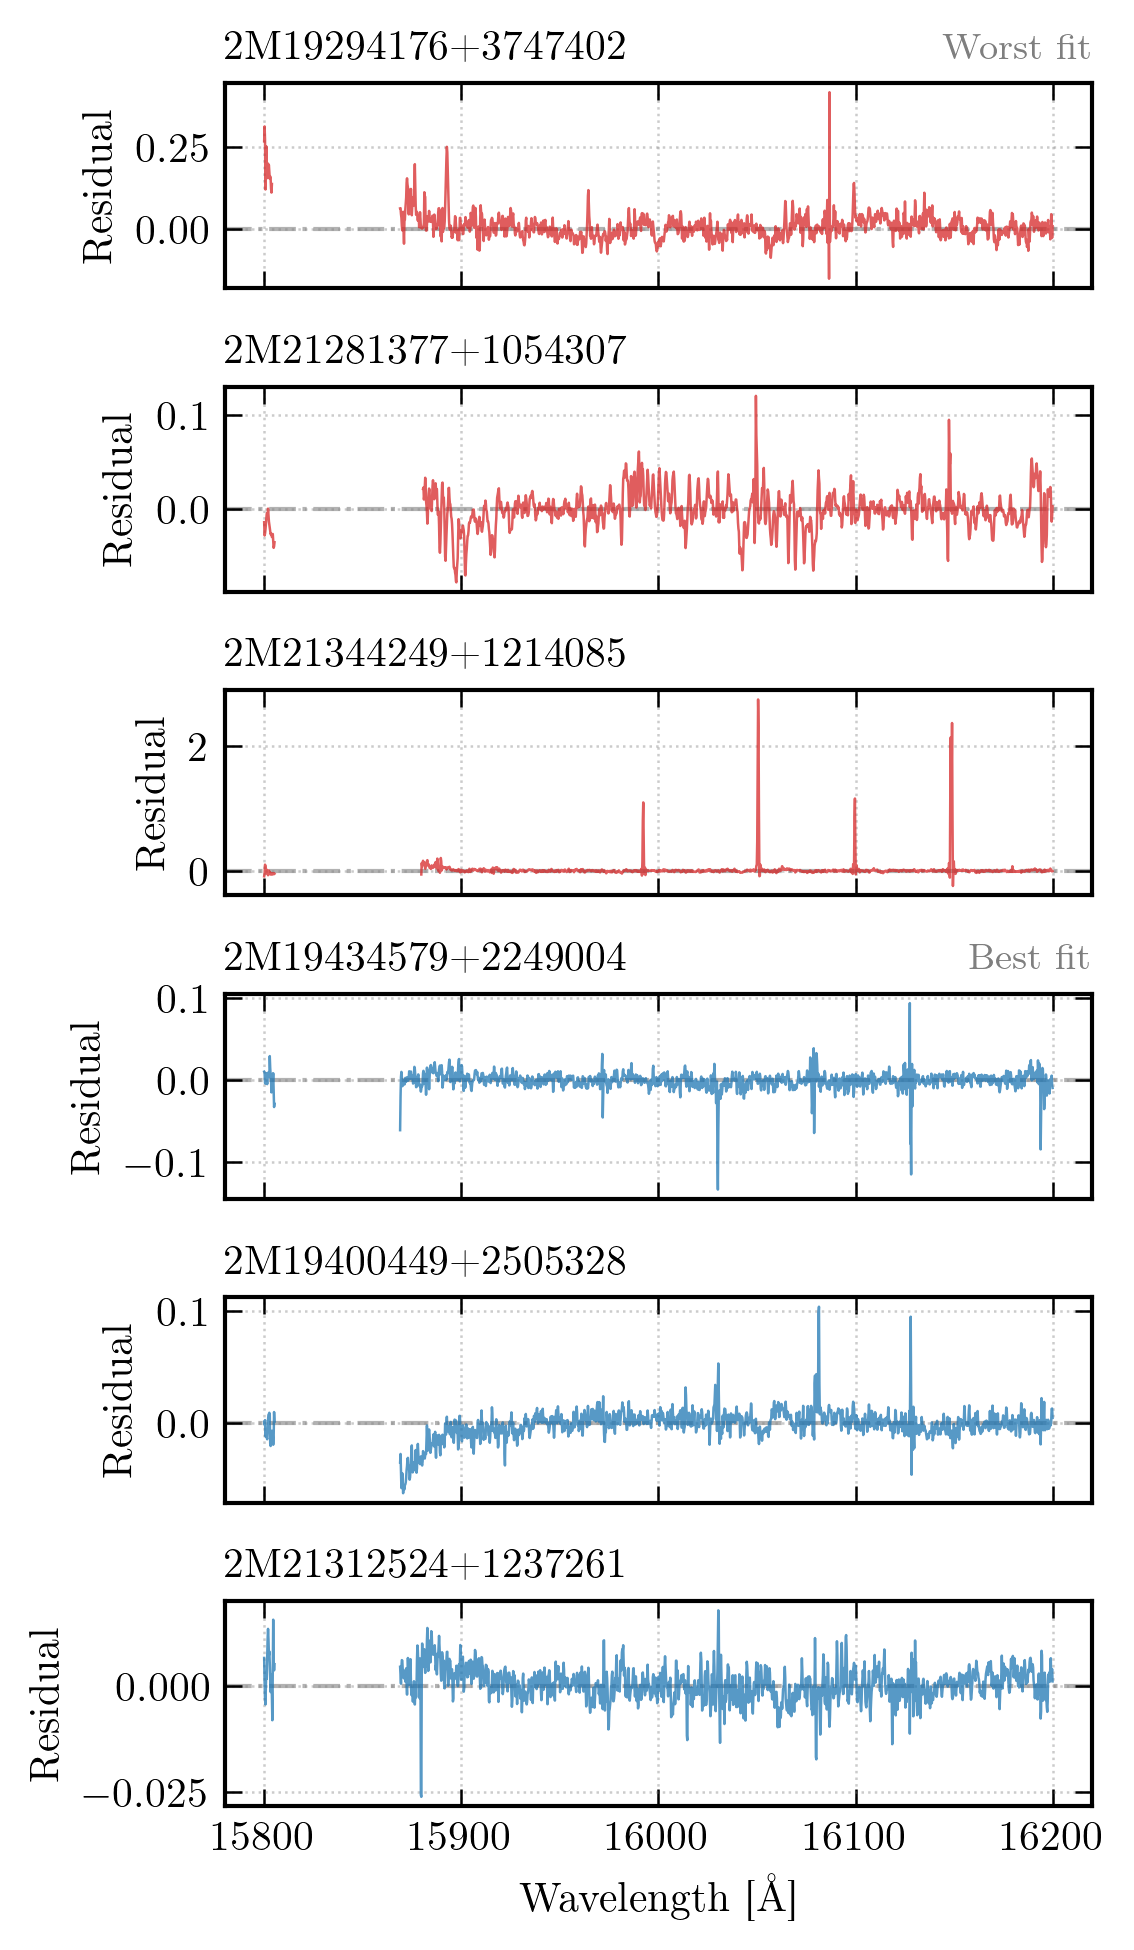

In [9]:
# Plot outlier spectra: 3 worst and 3 best
worst3_idx = np.argsort(norm_resid)[-3:][::-1]
best3_idx = np.argsort(norm_resid)[:3]

flux_pred_worst3 = np.array([model.predict(fitted_labels[idx]) for idx in worst3_idx])
flux_pred_best3 = np.array([model.predict(fitted_labels[idx]) for idx in best3_idx])

fig = plotters.plot_outlier_spectra(
    wavelength,
    flux_cv[worst3_idx], error_cv[worst3_idx], flux_pred_worst3, ids_cv[worst3_idx],
    flux_cv[best3_idx], error_cv[best3_idx], flux_pred_best3, ids_cv[best3_idx],
    wl_min=15800, wl_max=16200,
)
plt.show()

In [10]:
# Check ASPCAP flags for outliers
print("ASPCAP flags for outlier stars:")
for idx in worst_idx:
    print(f"  {ids_cv[idx]}: starflag={starflag[cv_idx[idx]]:#010x}, "
          f"aspcapflag={aspcapflag[cv_idx[idx]]:#010x}")

ASPCAP flags for outlier stars:
  2M19294176+3747402: starflag=0x00800004, aspcapflag=0x000042c0
  2M21281377+1054307: starflag=0x00000000, aspcapflag=0x00000004
  2M21344249+1214085: starflag=0x00000200, aspcapflag=0x00000040
  2M19445606+2411079: starflag=0x00000004, aspcapflag=0x00000044
  2M03595883+2418071: starflag=0x00000000, aspcapflag=0x00000000


In [11]:
# Check continuum normalization quality for outliers
continuum_mask = spec_data["continuum_mask"].astype(bool)

print("Continuum normalization quality for outlier stars:")
print(f"  {'ID':<25s} {'Mean cont px':>12s} {'Std cont px':>12s} {'% inf err':>10s}")
for idx in worst_idx:
    f_cont = flux_cv[idx, continuum_mask]
    e_cont = error_cv[idx, continuum_mask]
    valid = np.isfinite(f_cont) & (e_cont < np.inf)
    frac_inf = 1.0 - np.sum(valid) / len(f_cont)
    if np.sum(valid) > 0:
        print(f"  {ids_cv[idx]:<25s} {np.mean(f_cont[valid]):>12.4f} "
              f"{np.std(f_cont[valid]):>12.4f} {100*frac_inf:>9.1f}%")
    else:
        print(f"  {ids_cv[idx]:<25s} {'N/A':>12s} {'N/A':>12s} {100*frac_inf:>9.1f}%")

Continuum normalization quality for outlier stars:
  ID                        Mean cont px  Std cont px  % inf err
  2M19294176+3747402              1.0067       0.1561       0.0%
  2M21281377+1054307              0.9996       0.0148       0.0%
  2M21344249+1214085              1.0300       0.2552       0.0%
  2M19445606+2411079              1.0043       0.0407       0.0%
  2M03595883+2418071              1.0000       0.0136       0.0%


### Interpreting the outlier diagnostics

The four diagnostic blocks above (worst-fit ranking, optimizer-stuckness check, ASPCAP flag inspection, continuum-quality summary) need to be read together. Three patterns typically emerge:

1. **Optimizer-stuck stars** — fitted labels lie within 1% of the training-set mean in scaled space. These are stars where the trust-region optimizer never moved off the initial guess, usually because the local likelihood gradient was indistinguishable from numerical noise (extremely low SNR, almost-all-masked spectrum, or a spectrum that does not look like any training star). The fitted labels are meaningless for these stars; the large normalized residual is real.
2. **Bad-reference stars** — the optimizer converged on a sensible solution, the spectrum looks reasonable, but the fitted labels disagree strongly with ASPCAP because the *ASPCAP* labels are themselves unreliable. These stars usually carry a non-zero `aspcapflag` (parameter rails, sigma-truncation, or rejected calibration). The Cannon's fit is in fact more trustworthy than the reference here, but for the purposes of this notebook we are using ASPCAP as ground truth, so they show up as "outliers."
3. **Bad-spectrum stars** — the spectrum has an unflagged artifact (cosmic ray, persistent detector glitch, sky-subtraction failure) or a degraded continuum normalization (mean continuum-pixel flux significantly off unity, large fraction of masked pixels). The Cannon fit is genuinely poor at the residual level, and the labels are unreliable.


Outlier stars may have non-zero `starflag` or `aspcapflag` values indicating warnings from the ASPCAP pipeline (e.g., low SNR in certain wavelength regions, unreliable abundance determinations, or issues with the RV combination of visits). Stars with significant flag bits may have less reliable ASPCAP labels, making them poor reference points for evaluating the Cannon's performance.

For continuum normalization: if the mean of continuum pixels deviates significantly from 1.0, or if the fraction of masked (sentinel error $\sigma = 10^6$) pixels is unusually high, the normalization may have failed for that star. Poor normalization would introduce systematic biases in all fitted labels.

For stars where the optimizer converged away from the initial guess, the Cannon fit is meaningful but the ASPCAP reference labels themselves may be inaccurate.

### Can the model be improved based on these tests?

The outlier investigation suggests three potential interventions, each with trade-offs:

1. **Remove stars with unreliable ASPCAP reference labels** (non-zero `aspcapflag`). This would improve the *apparent* CV scatter by removing stars whose "ground truth" is itself wrong, but it does not improve the model — it only cleans the evaluation set. We apply this reasoning when interpreting the CV scatter rather than when constructing the training set.

2. **Remove stars with bad spectra or failed normalization** from the training set, then retrain. This is the most defensible intervention: a corrupted spectrum genuinely degrades the polynomial coefficients at affected wavelengths. However, the per-pixel intrinsic scatter term $s_\lambda^2$ already absorbs most of this damage — it inflates at wavelengths where outlier spectra introduce excess variance, effectively down-weighting those pixels in downstream label fits. The benefit of manual removal is therefore marginal unless the outlier is extreme (as in the single-star cosmic-ray spike identified in Problem 8).

3. **Reject stars that are poorly fit in label space** (e.g., $3\sigma$ clipping) and retrain. As discussed in the model selection section below, this is the most dangerous option: it preferentially removes stars at the edges of label space where the polynomial is weakest, effectively shrinking the model's domain. The resulting lower scatter is partly illusory — it reflects a narrower label range, not a better model.

**Our conclusion:** we retain the original training set and report the honest, full-sample CV scatter. The dominant source of outliers is sparse training coverage at the warm edge ($T_{\rm eff} > 5000$ K) and the subgiant boundary ($\log g > 3$), which is a limitation of the training data, not the model architecture. The most impactful improvement would be adding more training stars in these under-represented regions, not post-hoc cleaning of the existing sample.

### Improvements in The Cannon 2

Several of the limitations exposed by our outlier analysis were addressed in **The Cannon 2** (Casey et al. 2016), the successor to the original Ness et al. (2015) implementation:

1. **Regularization via censoring ("censored training").** The Cannon 2 allows individual pixels to be *censored* — excluded from the training of specific labels — based on whether the gradient at that pixel is statistically significant. This prevents the polynomial from fitting noise at wavelengths where a label has no real spectral signature, reducing the effective number of free parameters without changing the polynomial order. In our model, this would help at chip edges and in the inter-line continuum where the $[\mathrm{Mg/Fe}]$ and $[\mathrm{Si/Fe}]$ gradients are essentially zero but the polynomial still has nonzero quadratic coefficients driven by noise.

2. **Simultaneous continuum normalization.** Rather than normalizing spectra as a separate preprocessing step (as we do in Problem 4), The Cannon 2 can absorb the continuum into the model itself by including continuum-shape terms in the design vector. This eliminates the dependence on a fixed set of continuum pixels and removes the chip-edge normalization artifacts that contribute to our outlier population.

3. **Label transfer to larger surveys.** The Cannon 2 formalizes the use of a small, well-characterized training set (e.g., stars with asteroseismic $\log g$ from *Kepler*) to label a much larger survey sample. This addresses our sparse-coverage problem directly: rather than requiring dense training data across all of label space, the model is trained on a compact but high-fidelity reference set and applied to the full survey.

4. **Improved handling of bad pixels.** The Cannon 2 propagates per-pixel masks more carefully through the training step, giving zero weight to masked pixels in a way that is formally equivalent to marginalizing over missing data. Our sentinel-based approach ($\sigma = 10^6$) achieves a similar effect numerically, but the Cannon 2's formulation is cleaner and avoids the need to choose a sentinel threshold.

These improvements would collectively reduce the CV scatter and eliminate several of the outlier failure modes we identified above, particularly the chip-edge artifacts and the warm-edge degradation due to sparse coverage.

### Per-label worst deviators

The combined normalized residual above averages across all 5 labels, potentially masking stars that are extreme outliers in a single label but acceptable in others. We now inspect the 5 worst deviators for each label individually.

Worst 5 deviators in TEFF:
  1. 2M21261328+1139054: true=4624.9, fitted=5240.2, Δ=+615.2
  2. 2M19292252+3904095: true=5669.1, fitted=5199.4, Δ=-469.7
  3. 2M03581483+2537118: true=5660.6, fitted=5193.3, Δ=-467.3
  4. 2M19294176+3747402: true=4749.2, fitted=5163.2, Δ=+414.0
  5. 2M03564068+2603202: true=4803.7, fitted=4413.9, Δ=-389.8


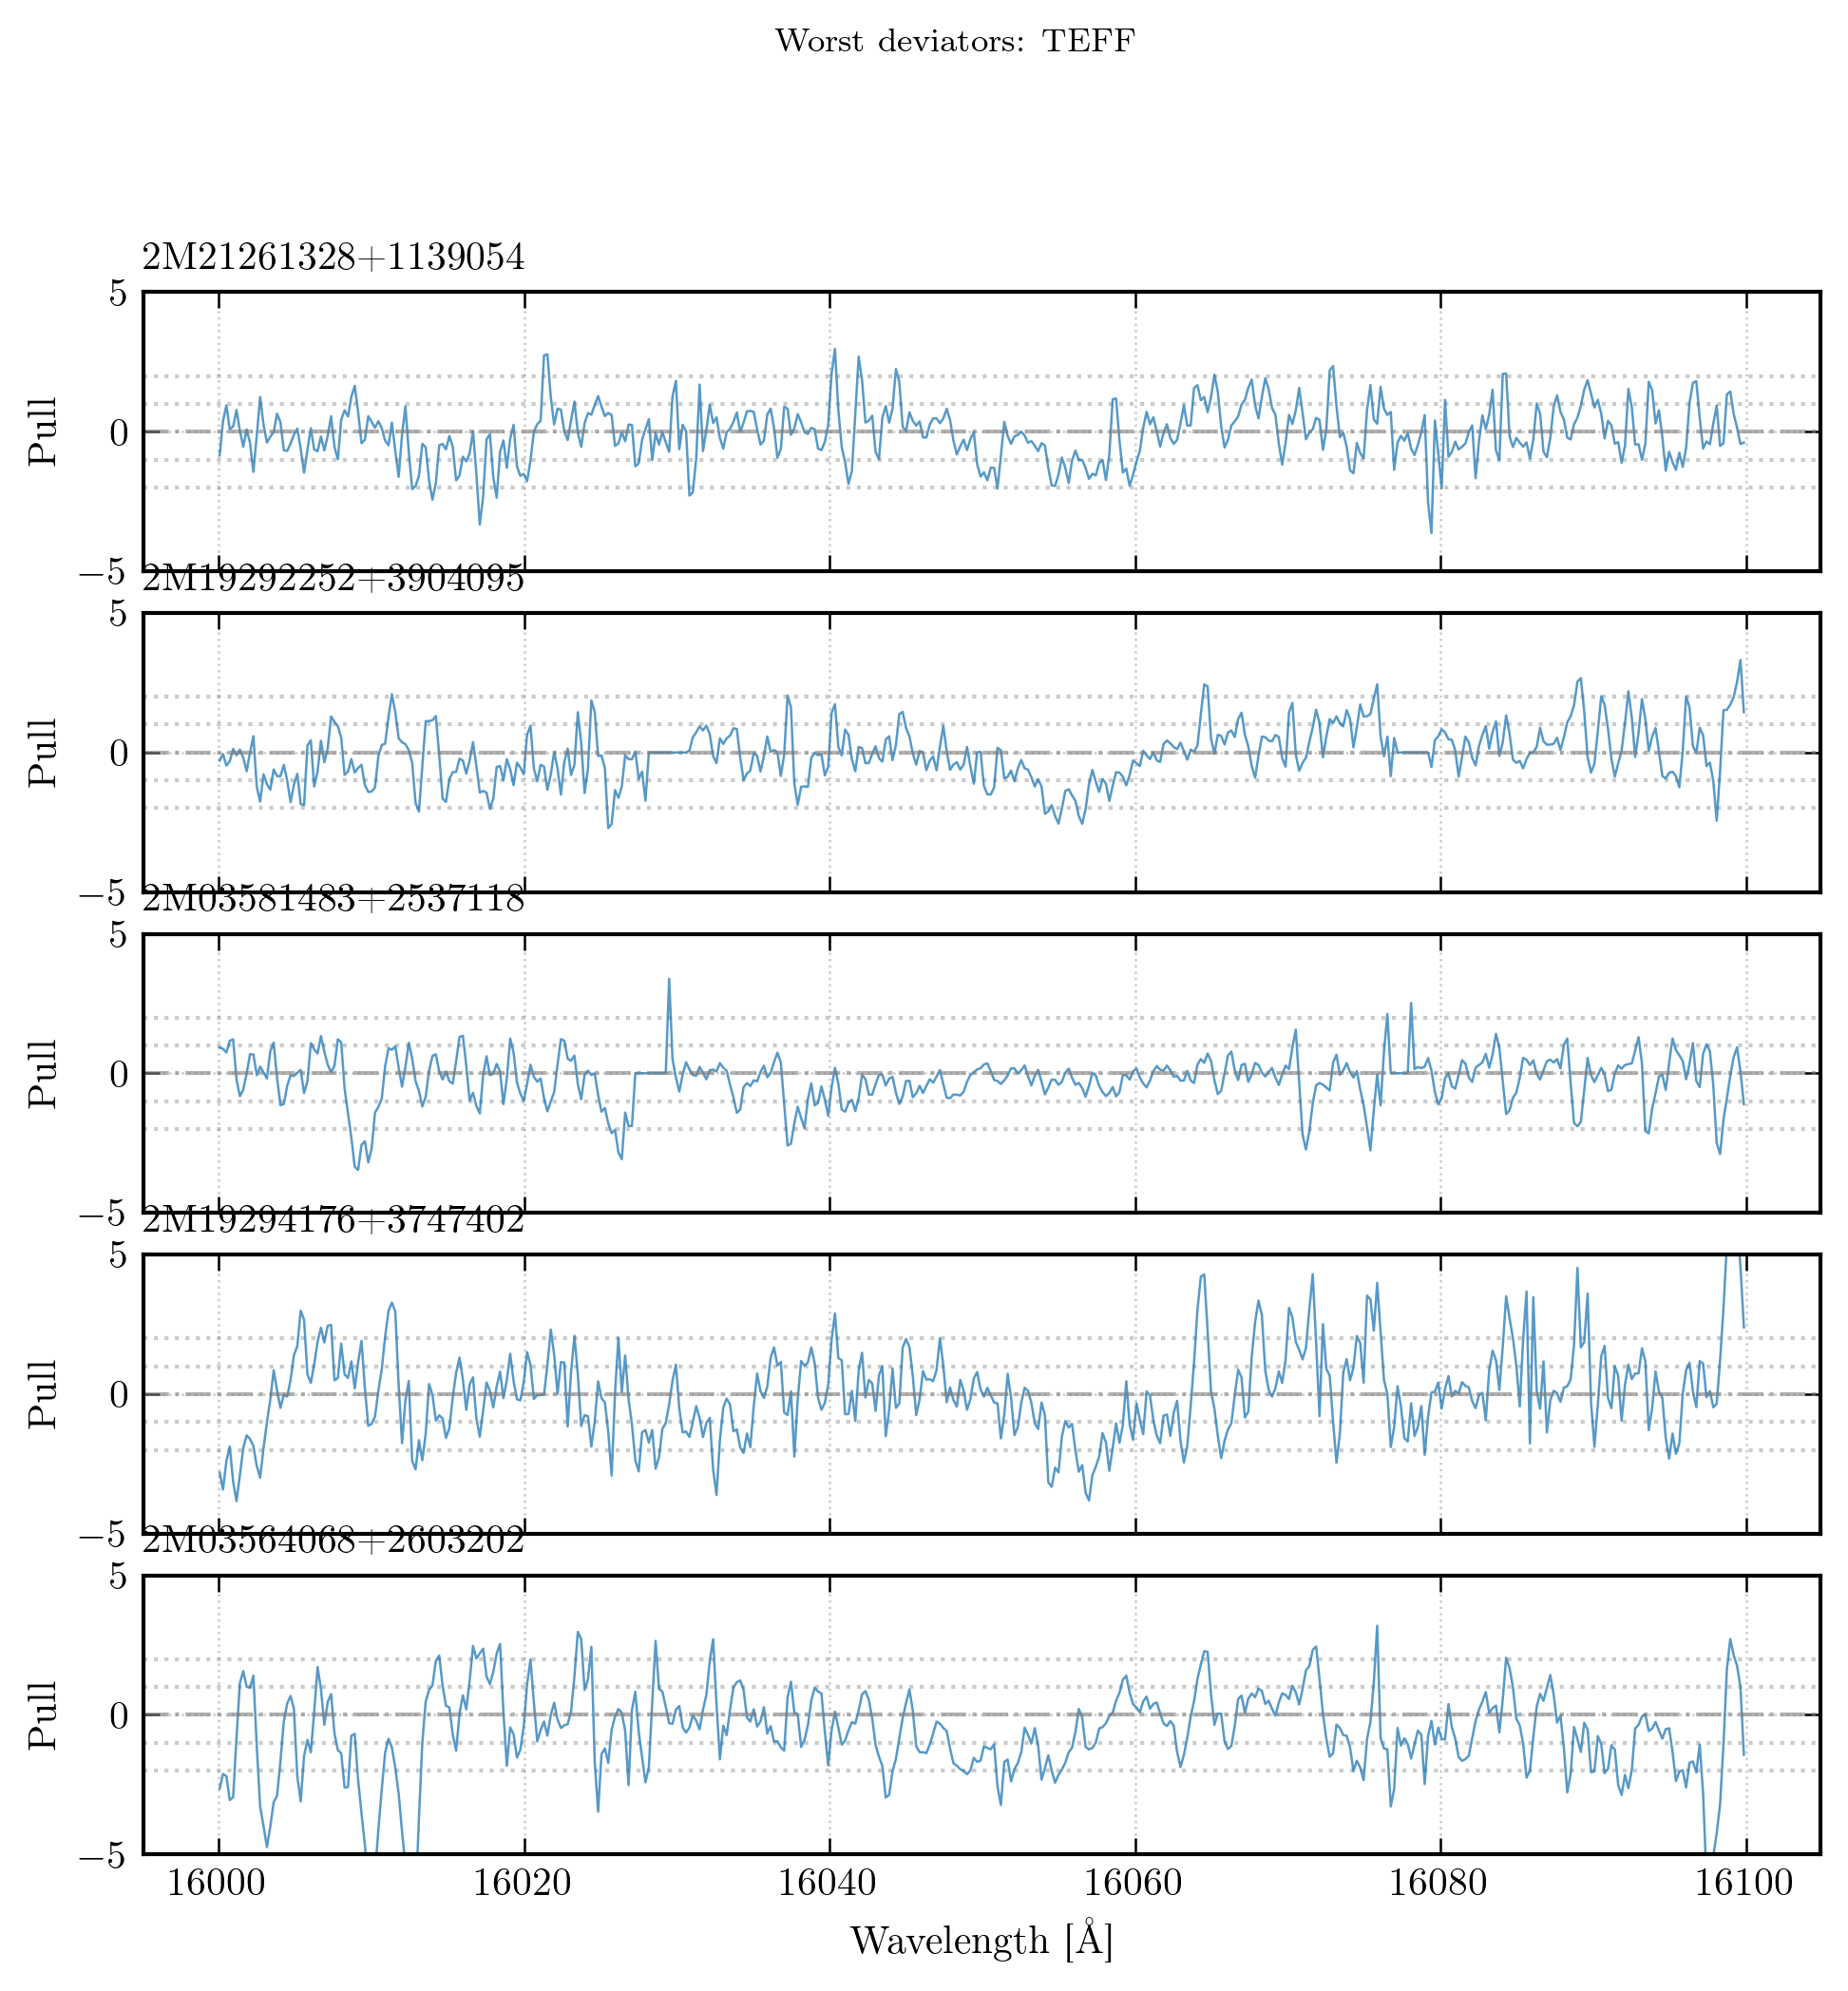

In [12]:
# Worst 5 deviators in Teff
i_label = 0
worst5 = np.argsort(np.abs(residuals[:, i_label]))[-5:][::-1]
print(f"Worst 5 deviators in {LABEL_NAMES[i_label]}:")
for rank, idx in enumerate(worst5):
    print(f"  {rank+1}. {ids_cv[idx]}: true={labels_cv[idx, i_label]:.1f}, "
          f"fitted={fitted_labels[idx, i_label]:.1f}, "
          f"\u0394={residuals[idx, i_label]:+.1f}")

flux_pred_w = np.array([model.predict(fitted_labels[idx]) for idx in worst5])
axes = plotters.plot_outlier_residuals(
    wavelength, flux_cv[worst5], error_cv[worst5], flux_pred_w,
    model.scatter, ids_cv[worst5], wl_min=16000, wl_max=16100,
)
plt.suptitle(f"Worst deviators: {LABEL_NAMES[i_label]}", y=1.01, fontsize="small")
plt.show()

Worst 5 deviators in LOGG:
  1. 2M21280685+1157477: true=3.152, fitted=2.467, Δ=-0.684
  2. 2M03564068+2603202: true=2.767, fitted=3.393, Δ=+0.625
  3. 2M19410898+2240121: true=3.154, fitted=2.547, Δ=-0.607
  4. 2M19464751+2354171: true=2.688, fitted=3.271, Δ=+0.583
  5. 2M19401787+2418231: true=2.868, fitted=3.444, Δ=+0.576


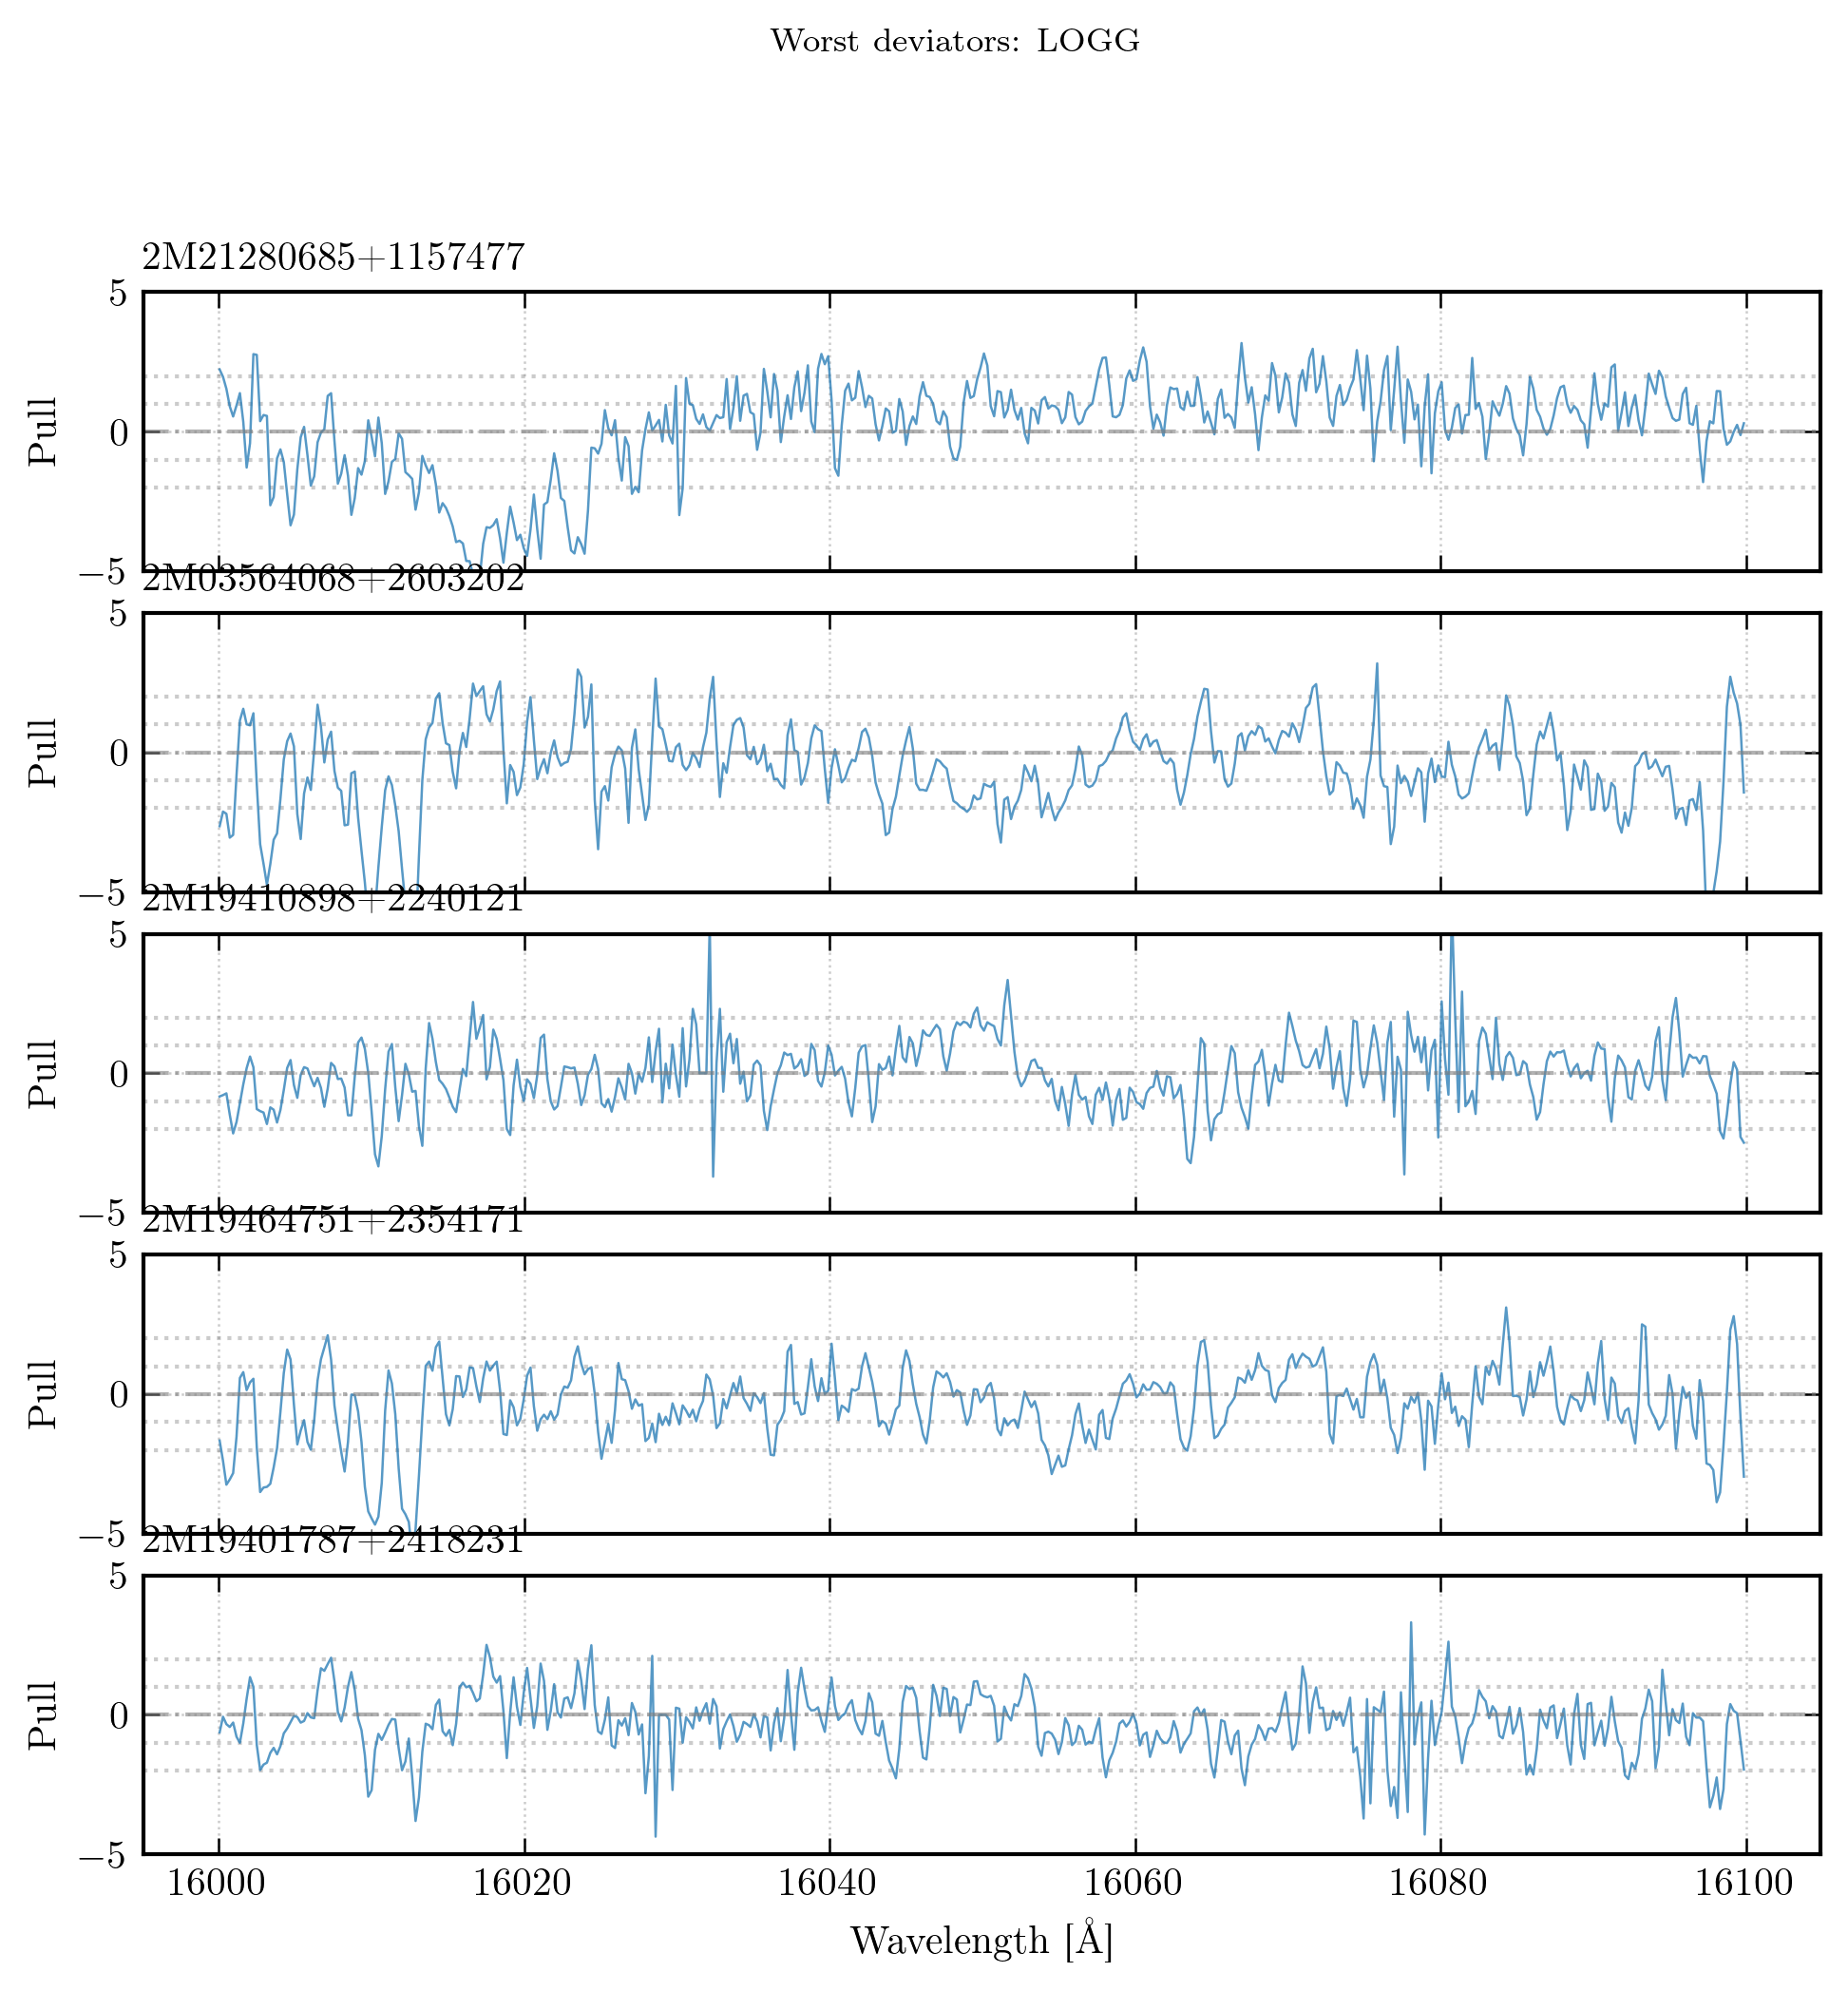

In [13]:
# Worst 5 deviators in logg
i_label = 1
worst5 = np.argsort(np.abs(residuals[:, i_label]))[-5:][::-1]
print(f"Worst 5 deviators in {LABEL_NAMES[i_label]}:")
for rank, idx in enumerate(worst5):
    print(f"  {rank+1}. {ids_cv[idx]}: true={labels_cv[idx, i_label]:.3f}, "
          f"fitted={fitted_labels[idx, i_label]:.3f}, "
          f"\u0394={residuals[idx, i_label]:+.3f}")

flux_pred_w = np.array([model.predict(fitted_labels[idx]) for idx in worst5])
axes = plotters.plot_outlier_residuals(
    wavelength, flux_cv[worst5], error_cv[worst5], flux_pred_w,
    model.scatter, ids_cv[worst5], wl_min=16000, wl_max=16100,
)
plt.suptitle(f"Worst deviators: {LABEL_NAMES[i_label]}", y=1.01, fontsize="small")
plt.show()

Worst 5 deviators in FE_H:
  1. 2M03564068+2603202: true=-0.068, fitted=-0.472, Δ=-0.405
  2. 2M21261328+1139054: true=-0.075, fitted=0.177, Δ=+0.252
  3. 2M03581483+2537118: true=-0.137, fitted=-0.377, Δ=-0.239
  4. 2M19292252+3904095: true=-0.106, fitted=-0.342, Δ=-0.236
  5. 2M19425211+2419119: true=-0.353, fitted=-0.585, Δ=-0.232


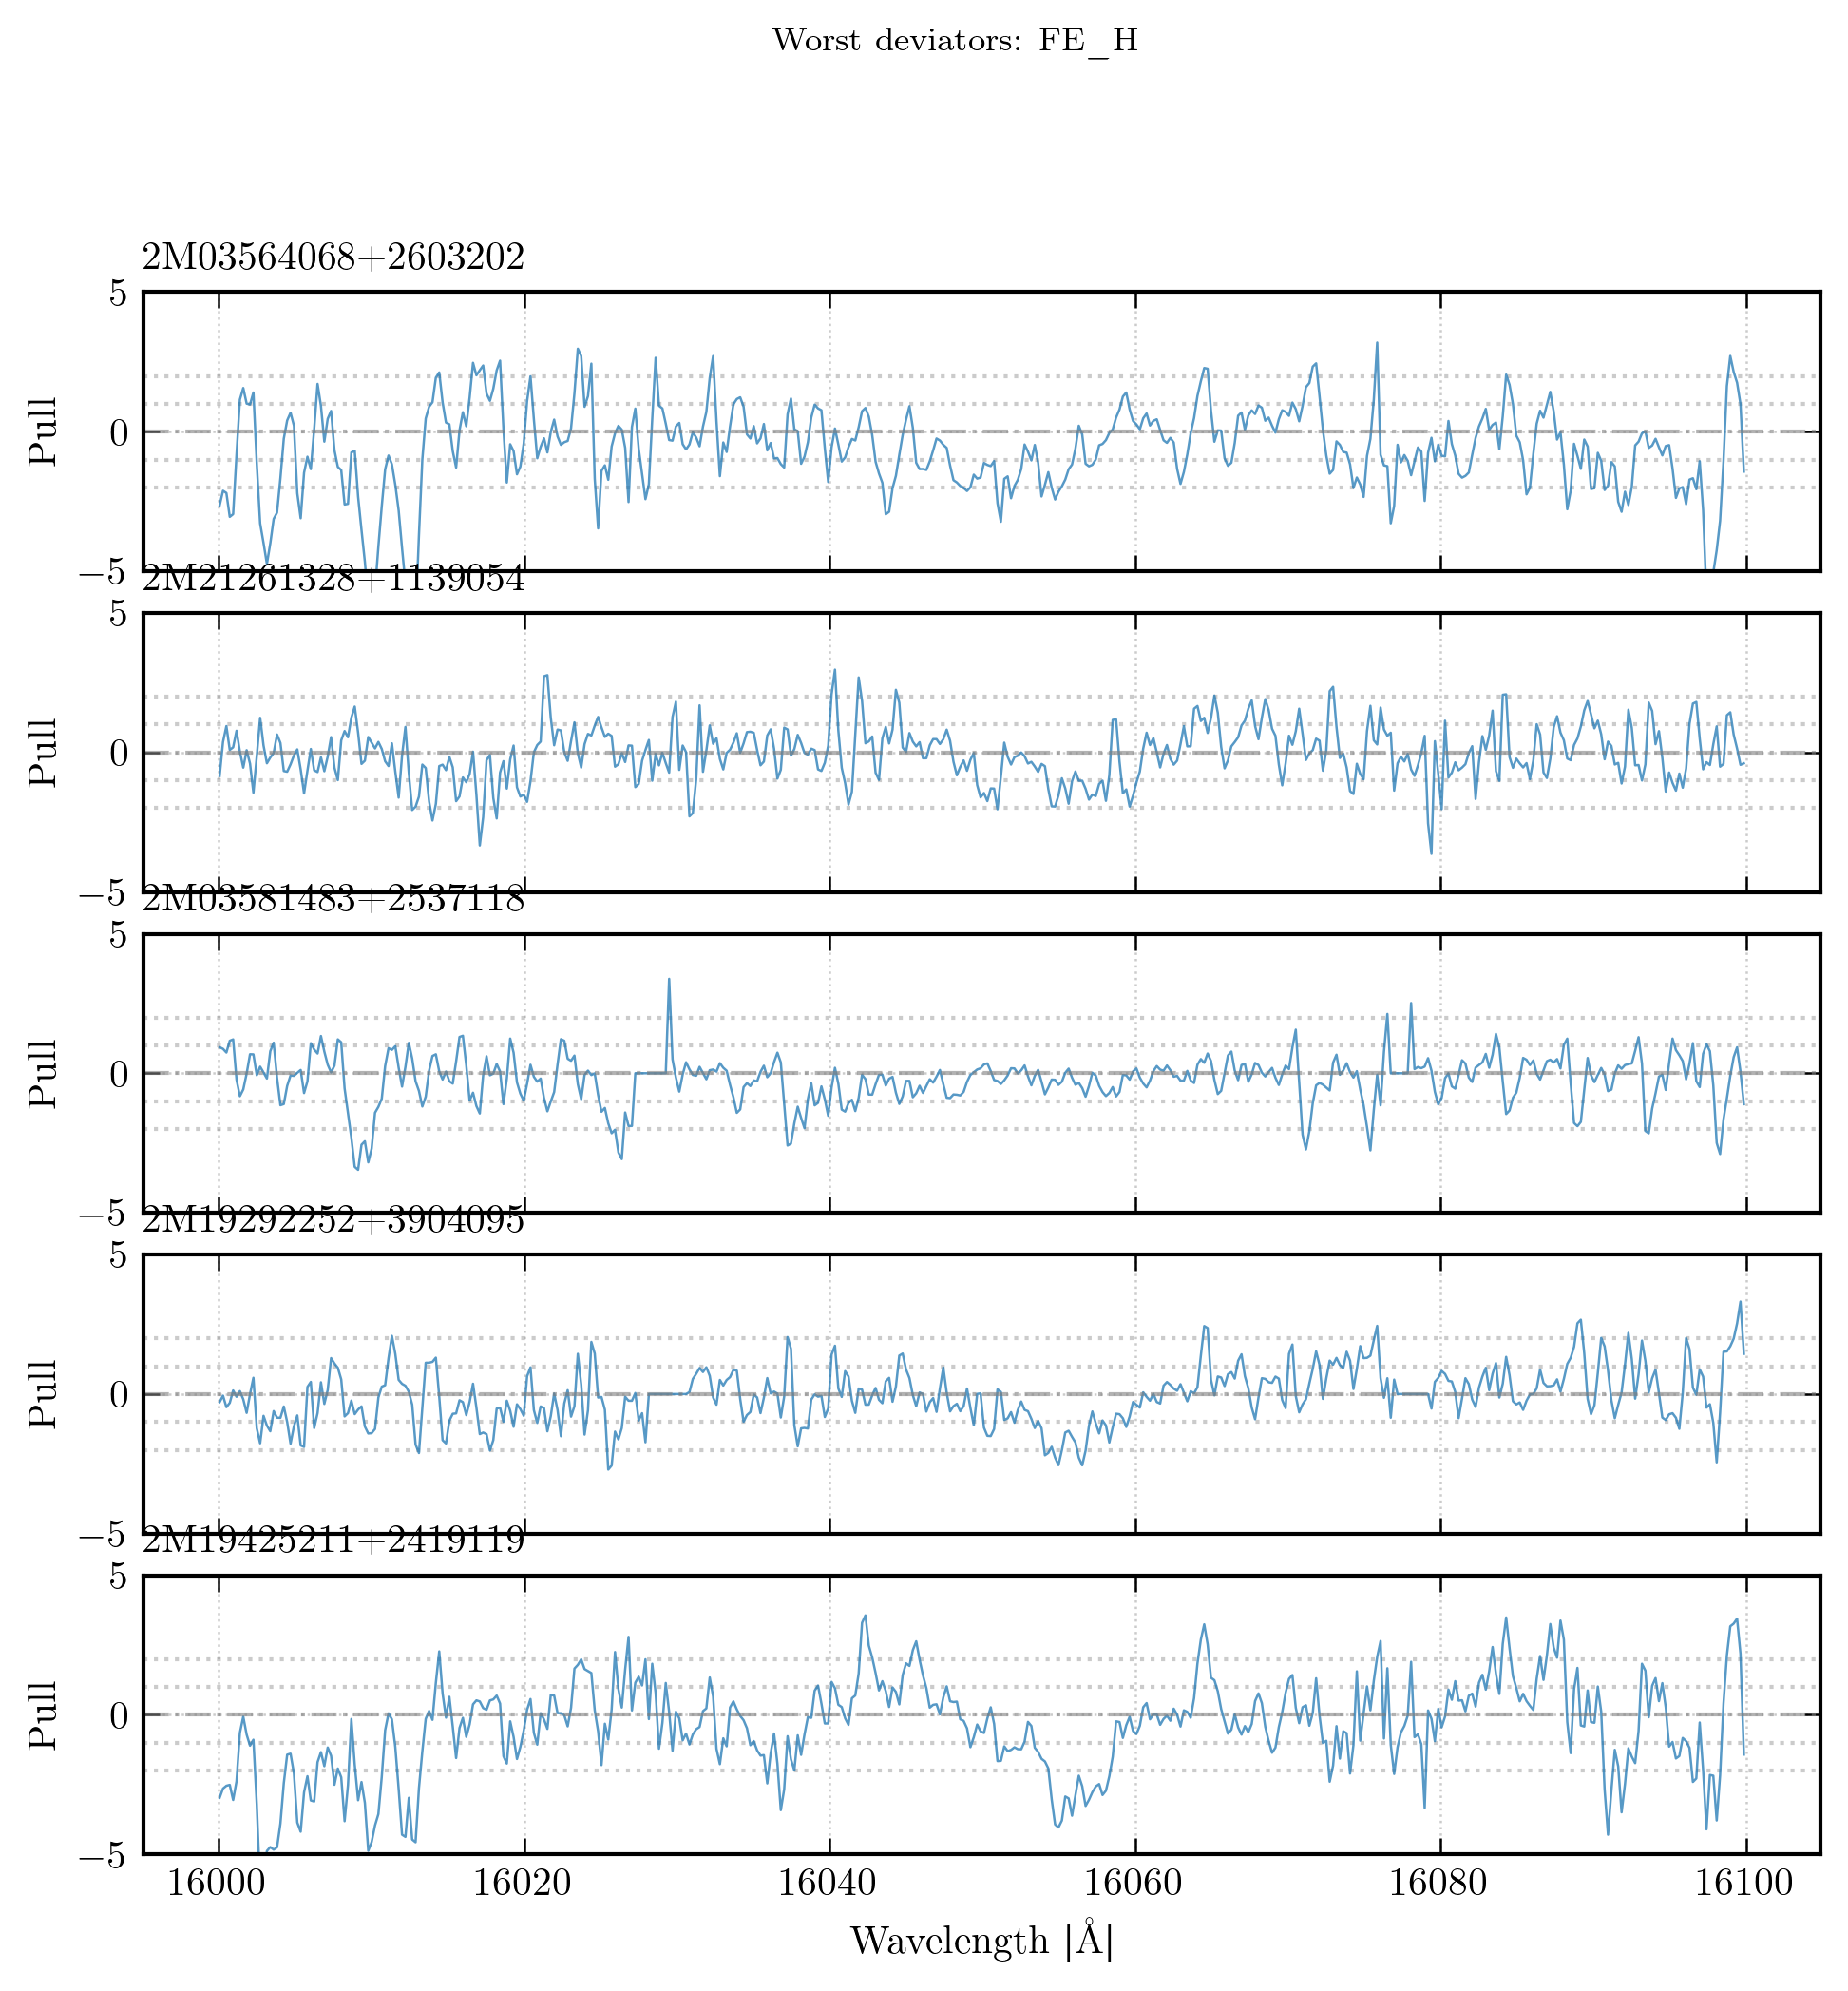

In [14]:
# Worst 5 deviators in [Fe/H]
i_label = 2
worst5 = np.argsort(np.abs(residuals[:, i_label]))[-5:][::-1]
print(f"Worst 5 deviators in {LABEL_NAMES[i_label]}:")
for rank, idx in enumerate(worst5):
    print(f"  {rank+1}. {ids_cv[idx]}: true={labels_cv[idx, i_label]:.3f}, "
          f"fitted={fitted_labels[idx, i_label]:.3f}, "
          f"\u0394={residuals[idx, i_label]:+.3f}")

flux_pred_w = np.array([model.predict(fitted_labels[idx]) for idx in worst5])
axes = plotters.plot_outlier_residuals(
    wavelength, flux_cv[worst5], error_cv[worst5], flux_pred_w,
    model.scatter, ids_cv[worst5], wl_min=16000, wl_max=16100,
)
plt.suptitle(f"Worst deviators: {LABEL_NAMES[i_label]}", y=1.01, fontsize="small")
plt.show()

Worst 5 deviators in MG_FE:
  1. 2M21344249+1214085: true=0.011, fitted=0.339, Δ=+0.328
  2. 2M21281377+1054307: true=0.014, fitted=0.303, Δ=+0.289
  3. 2M19282563+3741232: true=0.299, fitted=0.074, Δ=-0.225
  4. 2M19425211+2419119: true=0.116, fitted=-0.106, Δ=-0.221
  5. 2M19294176+3747402: true=0.098, fitted=-0.098, Δ=-0.196


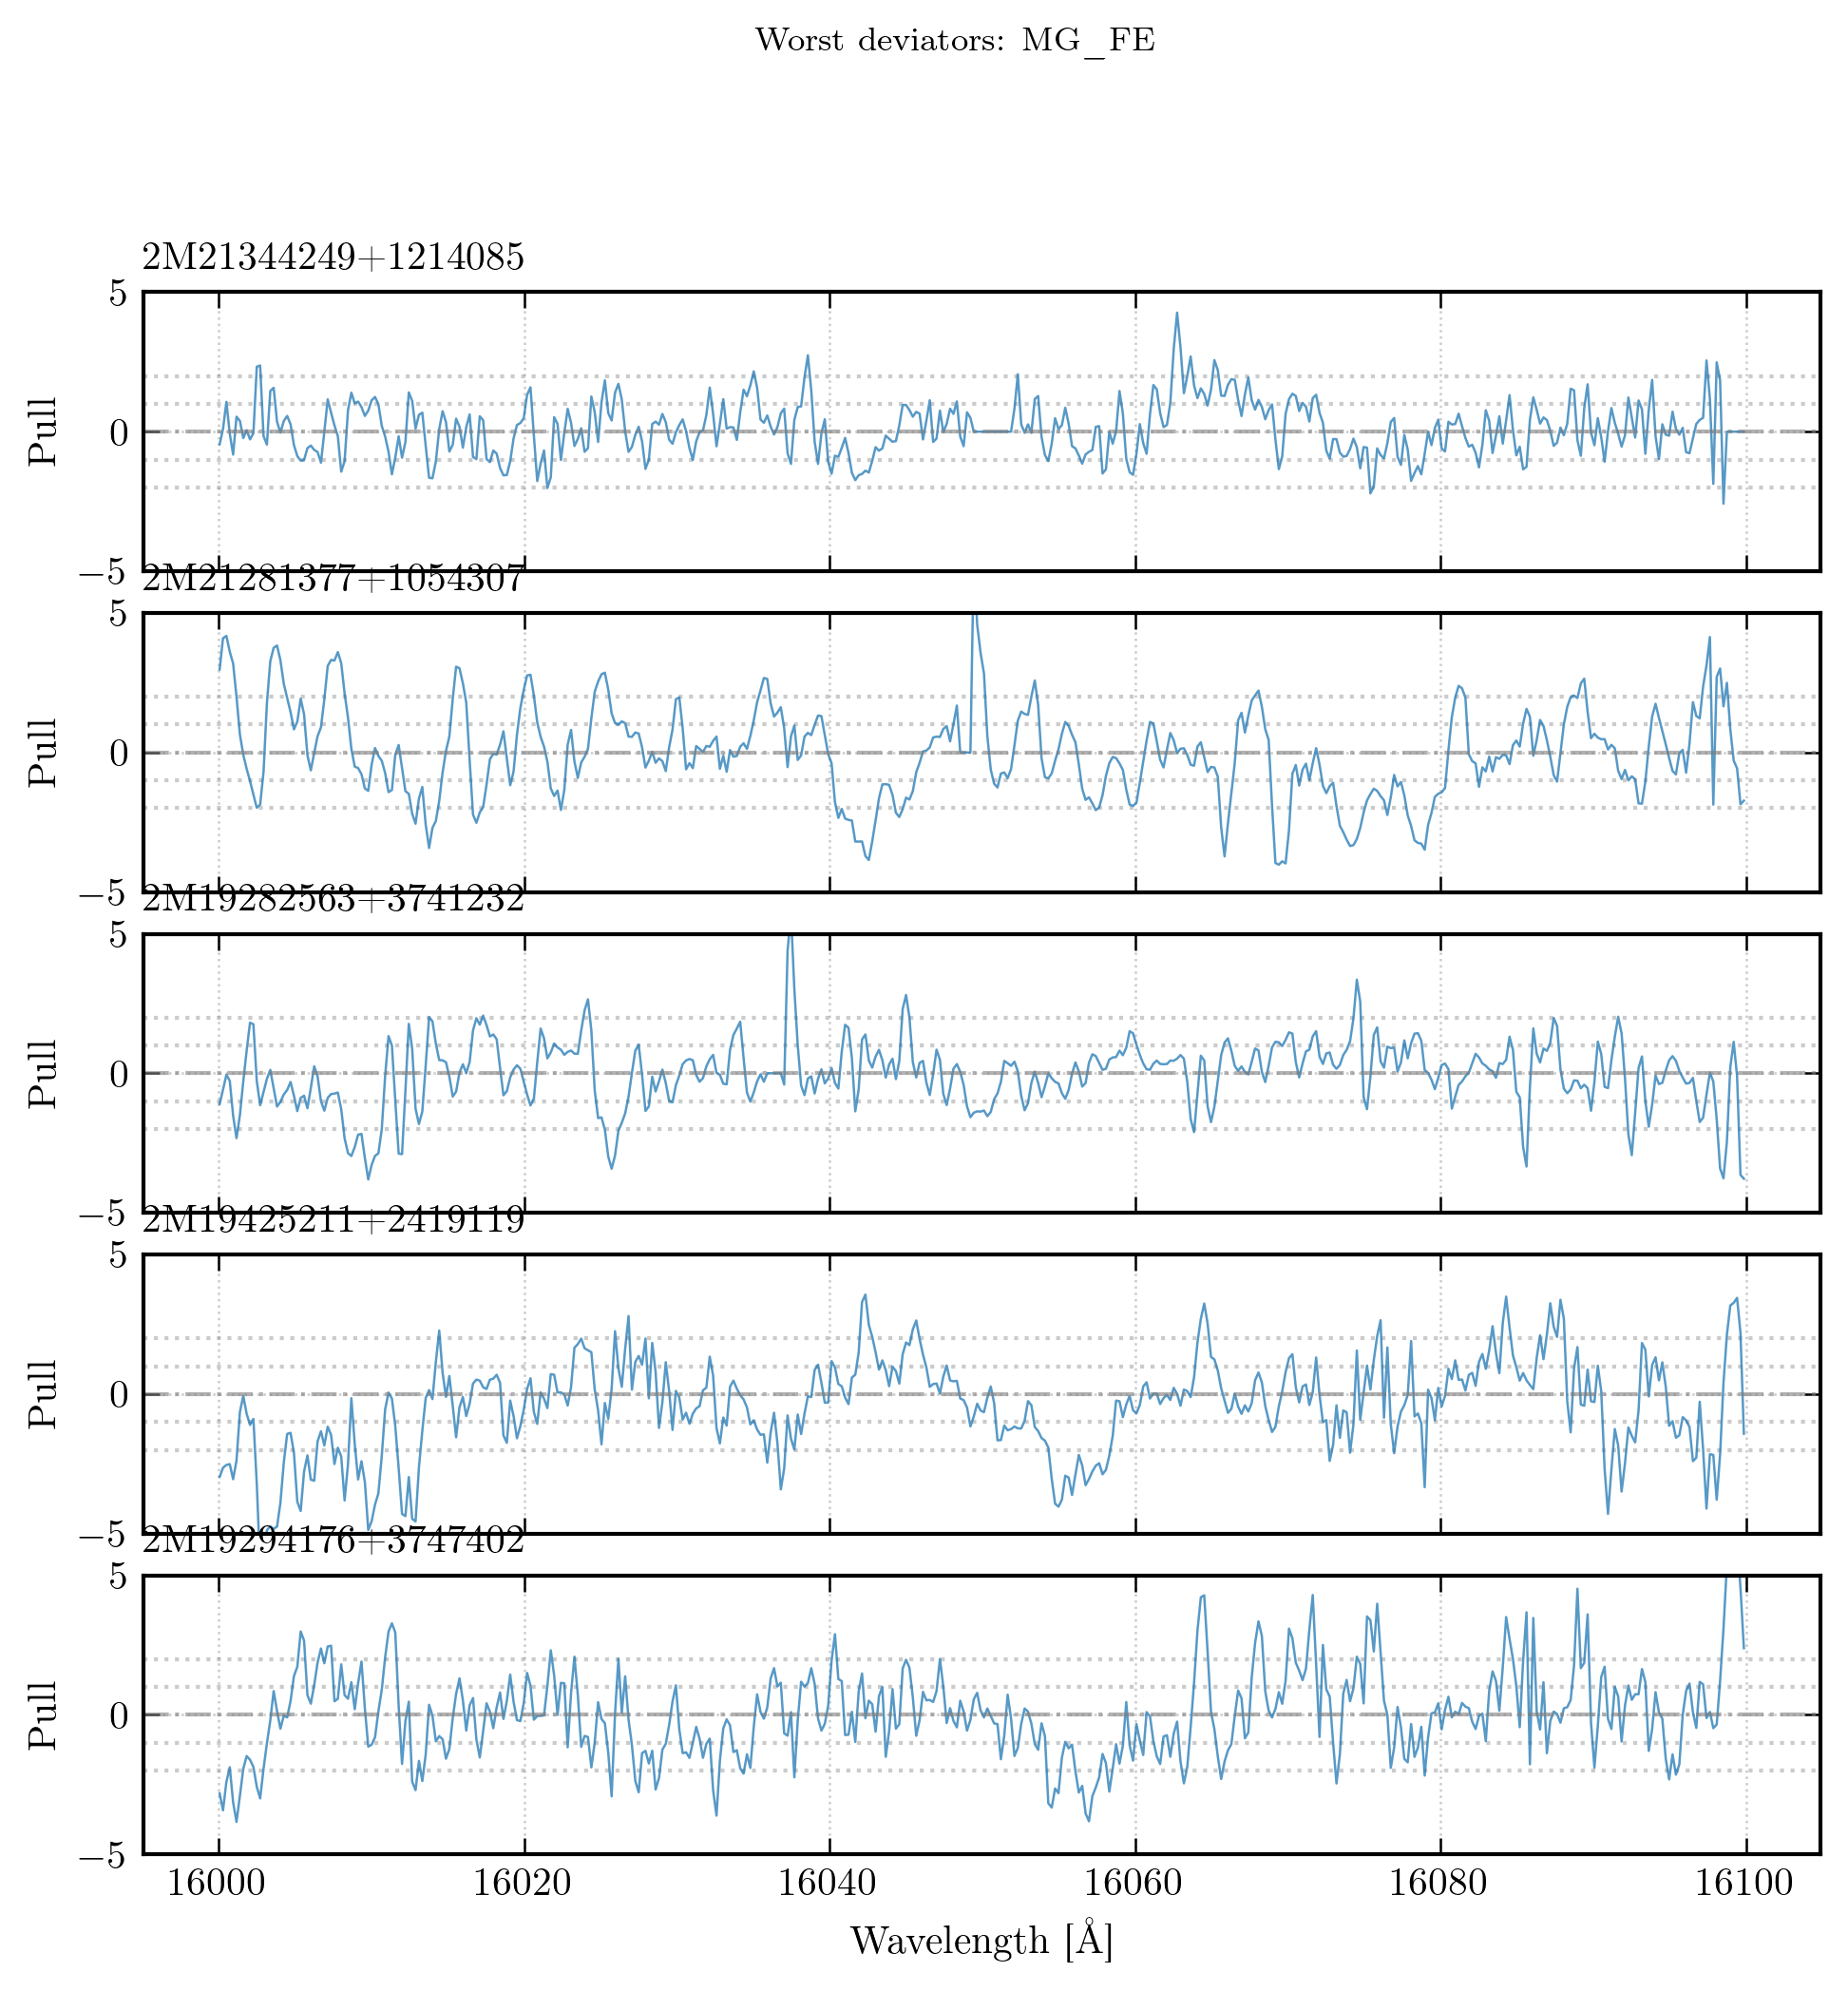

In [15]:
# Worst 5 deviators in [Mg/Fe]
i_label = 3
worst5 = np.argsort(np.abs(residuals[:, i_label]))[-5:][::-1]
print(f"Worst 5 deviators in {LABEL_NAMES[i_label]}:")
for rank, idx in enumerate(worst5):
    print(f"  {rank+1}. {ids_cv[idx]}: true={labels_cv[idx, i_label]:.3f}, "
          f"fitted={fitted_labels[idx, i_label]:.3f}, "
          f"\u0394={residuals[idx, i_label]:+.3f}")

flux_pred_w = np.array([model.predict(fitted_labels[idx]) for idx in worst5])
axes = plotters.plot_outlier_residuals(
    wavelength, flux_cv[worst5], error_cv[worst5], flux_pred_w,
    model.scatter, ids_cv[worst5], wl_min=16000, wl_max=16100,
)
plt.suptitle(f"Worst deviators: {LABEL_NAMES[i_label]}", y=1.01, fontsize="small")
plt.show()

Worst 5 deviators in SI_FE:
  1. 2M19294176+3747402: true=-0.480, fitted=0.009, Δ=+0.489
  2. 2M19445606+2411079: true=0.146, fitted=-0.121, Δ=-0.266
  3. 2M21281377+1054307: true=0.000, fitted=0.228, Δ=+0.228
  4. 2M19465744+2511396: true=0.040, fitted=-0.150, Δ=-0.190
  5. 2M21344249+1214085: true=0.045, fitted=0.232, Δ=+0.187


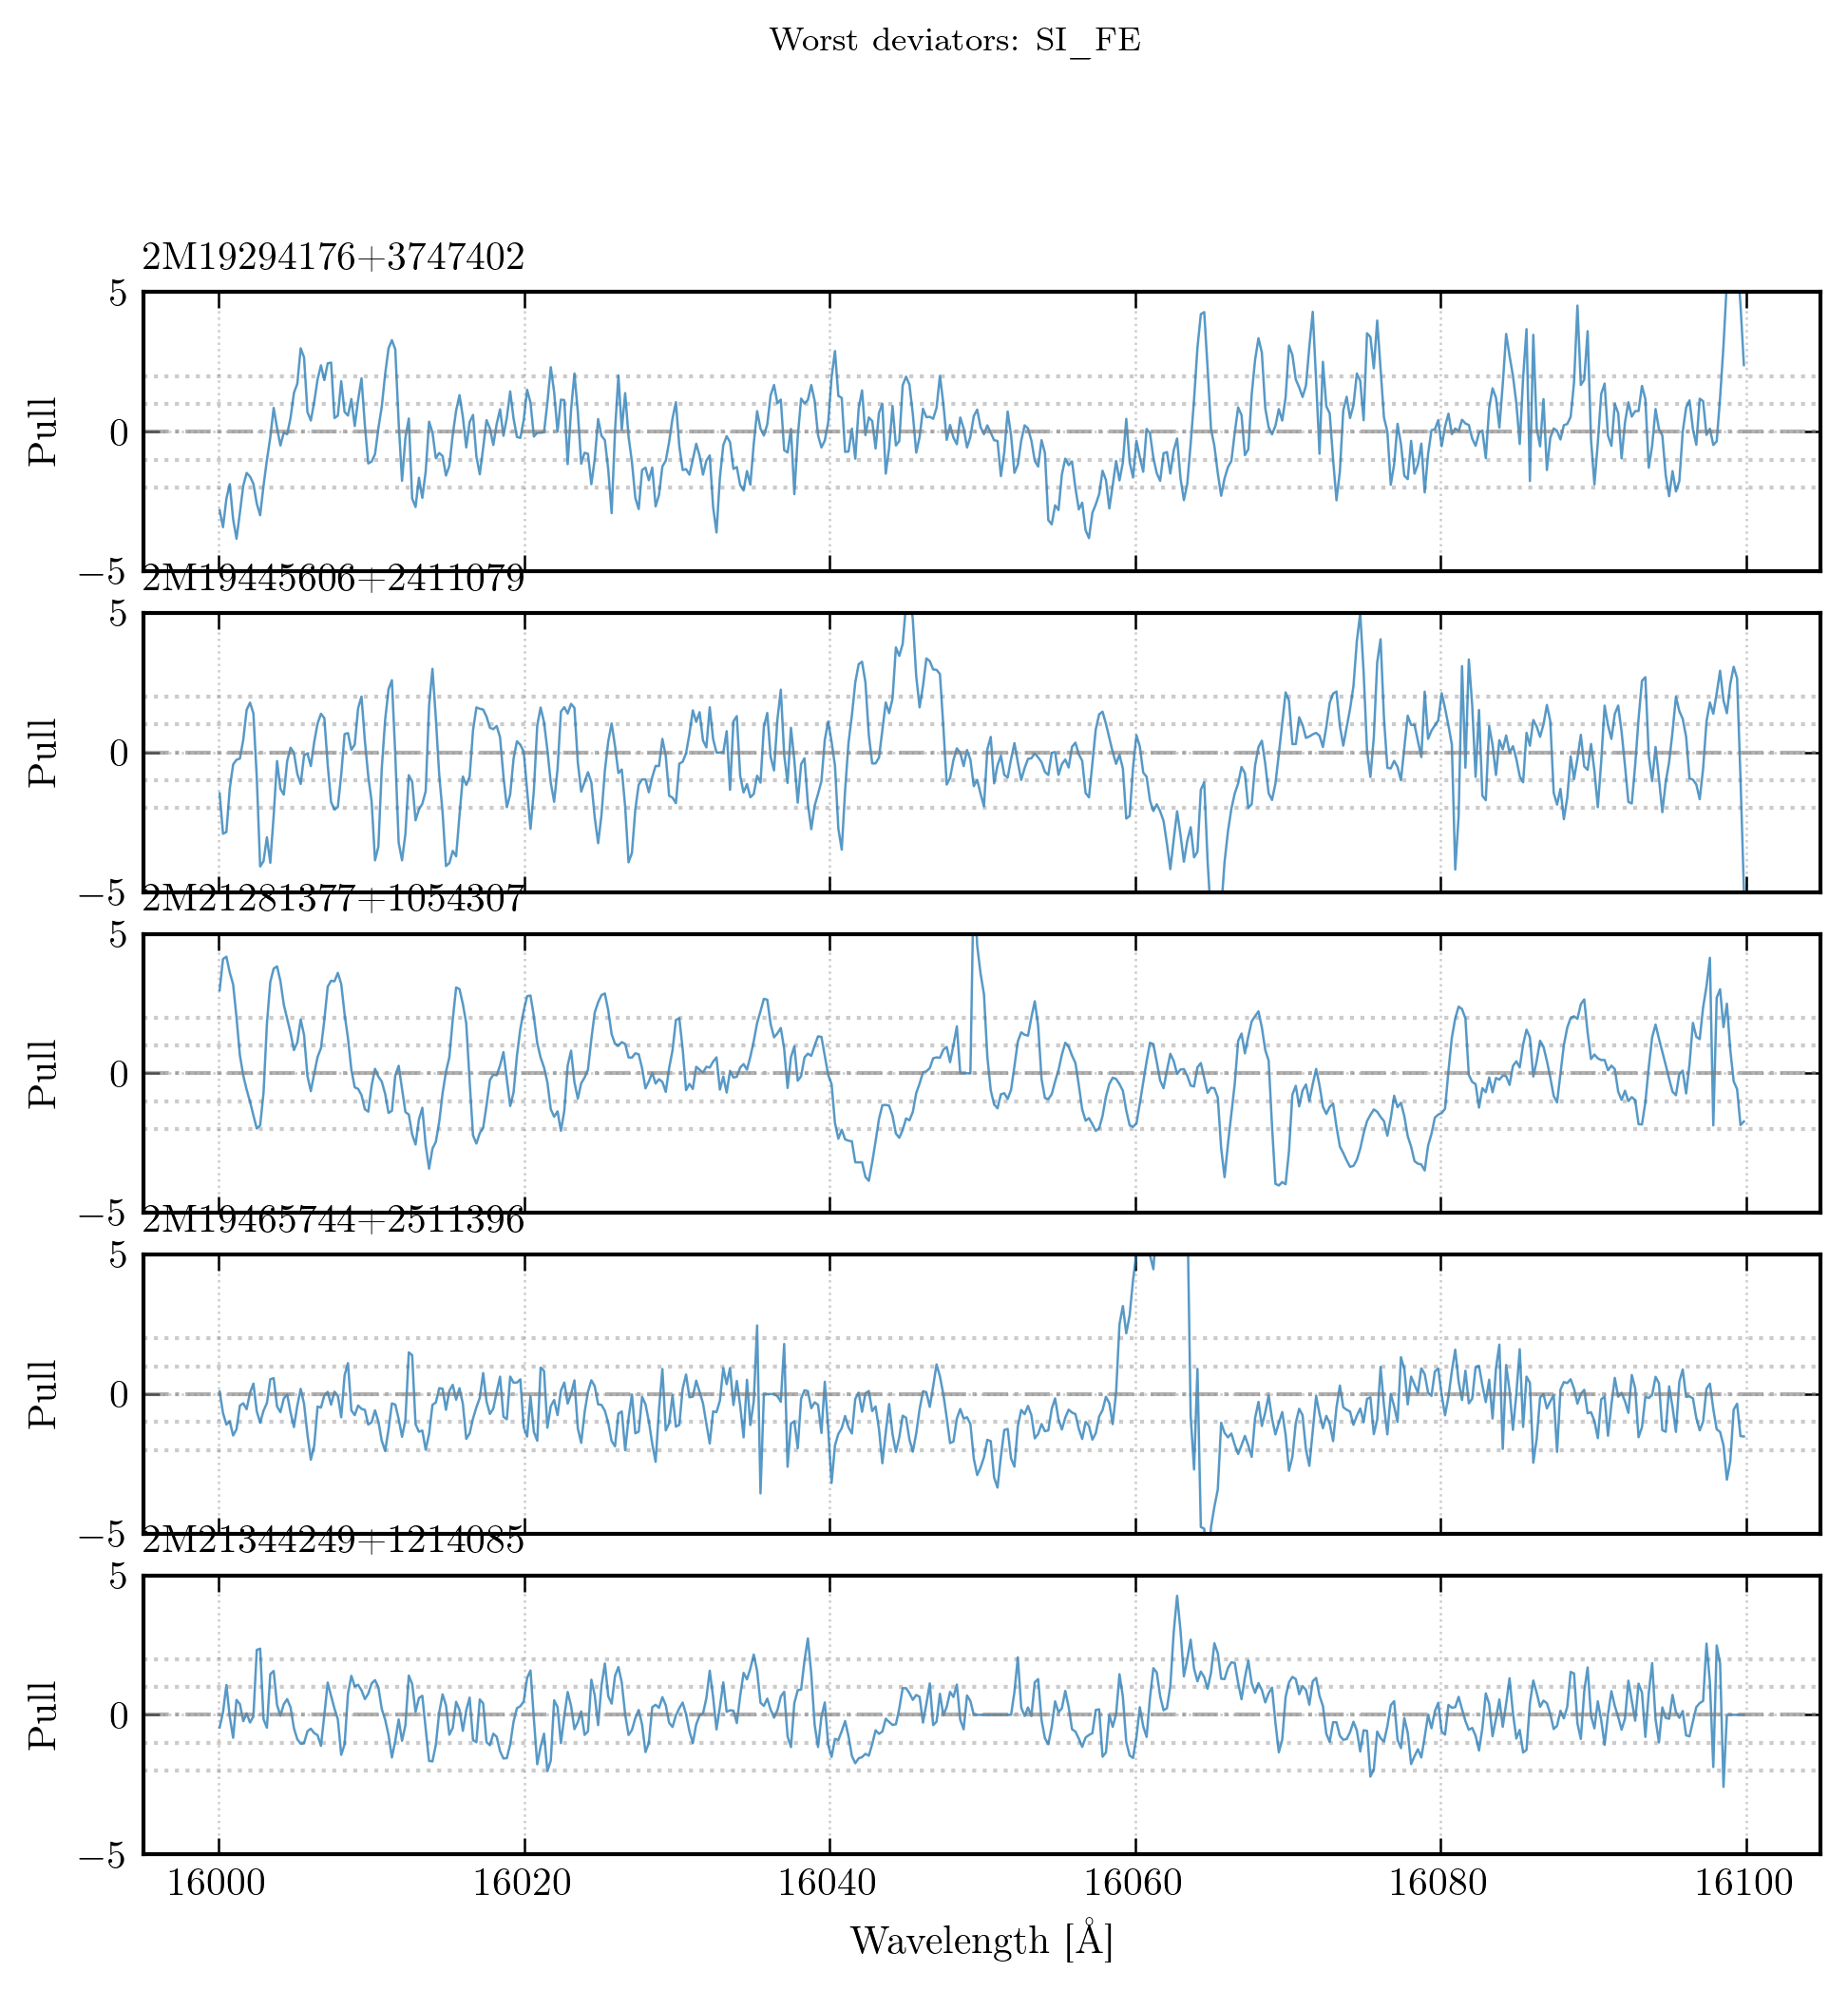

In [16]:
# Worst 5 deviators in [Si/Fe]
i_label = 4
worst5 = np.argsort(np.abs(residuals[:, i_label]))[-5:][::-1]
print(f"Worst 5 deviators in {LABEL_NAMES[i_label]}:")
for rank, idx in enumerate(worst5):
    print(f"  {rank+1}. {ids_cv[idx]}: true={labels_cv[idx, i_label]:.3f}, "
          f"fitted={fitted_labels[idx, i_label]:.3f}, "
          f"\u0394={residuals[idx, i_label]:+.3f}")

flux_pred_w = np.array([model.predict(fitted_labels[idx]) for idx in worst5])
axes = plotters.plot_outlier_residuals(
    wavelength, flux_cv[worst5], error_cv[worst5], flux_pred_w,
    model.scatter, ids_cv[worst5], wl_min=16000, wl_max=16100,
)
plt.suptitle(f"Worst deviators: {LABEL_NAMES[i_label]}", y=1.01, fontsize="small")
plt.show()

## Problem 11 — Kiel Diagram

### MIST isochrones

We retrieve **MIST** (MESA Isochrones and Stellar Tracks; Choi et al. 2016) isochrones at $[\mathrm{Fe/H}] = 0$ and $[\mathrm{Fe/H}] = -1$ for an age of 6 Gyr to overlay on the Kiel diagram. Two choices to justify:

- **Why 6 Gyr?** The disk and bulge fields in our training set are dominated by intermediate-age, evolved stars; 6 Gyr is a conventional intermediate age that produces a well-developed RGB and a populated red clump, and is the age that best reproduces the dense red-clump knot we already saw in the training-set Kiel diagram (NB 01). Both M15 (~13 Gyr) and NGC 6791 (~8 Gyr) are older, but isochrone shape on the upper RGB is only weakly age-dependent in this regime, so a 6 Gyr track is an adequate visual reference for *all* of our cluster and field stars.
- **Why MIST?** MIST provides broad coverage of $[\mathrm{Fe/H}]$ on a regular grid with consistent input physics, and is the standard reference grid in the APOGEE community. Padova and BaSTI would give very similar tracks for these regions; the choice is one of convenience rather than physics.


In [17]:
iso_solar = _get_mist_isochrone(6.0, 0.0)
iso_metal_poor = _get_mist_isochrone(6.0, -1.0)

print(f"[Fe/H]=0 isochrone: {len(iso_solar)} points, "
      f"Teff range {iso_solar['Teff'].min():.0f}–{iso_solar['Teff'].max():.0f} K")
print(f"[Fe/H]=-1 isochrone: {len(iso_metal_poor)} points, "
      f"Teff range {iso_metal_poor['Teff'].min():.0f}–{iso_metal_poor['Teff'].max():.0f} K")

[Fe/H]=0 isochrone: 1430 points, Teff range 2811–122983 K
[Fe/H]=-1 isochrone: 1424 points, Teff range 3095–113680 K


### Kiel diagram

The Kiel diagram ($\log g$ vs $T_{\rm eff}$) reveals evolutionary structure in the CV set using **Cannon-fitted labels** (not ASPCAP). With both axes inverted (hot→cold left→right, low gravity at top), we identify the following known features:

- **Red giant branch (RGB):** the dominant ascending track from $(\log g, T_{\rm eff}) \approx (3.5, 5000\,\mathrm{K})$ to $(0.5, 3800\,\mathrm{K})$. Stars spend most of their post-main-sequence lifetime ascending the RGB, so it is the most populated structure.
- **Red clump:** a dense horizontal concentration near $\log g \approx 2$–$2.5$, $T_{\rm eff} \approx 4700$–$4900\,\mathrm{K}$. These are core-helium-burning stars that have undergone the helium flash and contracted back to $R \sim 10$–$15\,R_\odot$. The clump is clearly visible as a local over-density in the diagram.
- **Subgiant branch:** a sparse population near $\log g \approx 3.5$–$4.0$, $T_{\rm eff} \approx 4800$–$5500\,\mathrm{K}$, at the base of the RGB. Stars cross this region rapidly, so it is under-populated.
- **Absent features:** the horizontal branch (HB) and asymptotic giant branch (AGB) are not clearly separable from the RGB in this diagram. The $[\mathrm{Fe/H}] \geq -1$ cut removed the most metal-poor stars where the HB would be prominent, and the AGB overlaps the RGB in $(\log g, T_{\rm eff})$ space.

**Trends with $[\mathrm{Fe/H}]$.** Color-coding by fitted $[\mathrm{Fe/H}]$ reveals a clear metallicity gradient across the RGB: metal-rich stars (red/warm colors) are systematically cooler at fixed $\log g$ than metal-poor stars (blue/cool colors). This is the expected opacity effect — higher metallicity increases line blanketing in the photosphere, which redistributes emergent flux from blue to red and lowers $T_{\rm eff}$ at fixed luminosity and $\log g$ (see Holtzman et al. 2015, their Figures 7–8 for comparison). The gradient is smooth and monotonic, with no sharp discontinuities, confirming that the Cannon's fitted labels produce physically consistent trends.

**Comparison to MIST isochrones — how good is the agreement?** The fitted CV-set Kiel diagram is overlaid with 6 Gyr MIST isochrones (Choi et al. 2016) at $[\mathrm{Fe/H}] = 0$ and $-1$:

1. **Overall RGB shape: good agreement.** The bulk of the data points follow the curved RGB ridge of the solar-metallicity isochrone from the subgiant boundary up to the RGB tip. The shape agreement confirms that the Cannon's independently fitted $T_{\rm eff}$ and $\log g$ are physically consistent — a star fit from its spectrum alone lands where stellar-evolution models predict a giant of that metallicity should be.

2. **Red-clump position: good agreement.** The observed clump sits near the isochrone's core-He-burning phase, close to the analytic red-clump value $\log g \approx 2.08$ derived in NB 01 (from $g = GM/R^2$ for $R \approx 15\,R_\odot$). Any offset is within the $\sim 0.13$ dex CV scatter in $\log g$.

3. **Does the $[\mathrm{Fe/H}]$-trend in the isochrones agree with the fitting? Yes.** The $[\mathrm{Fe/H}] = -1$ isochrone is shifted to hotter $T_{\rm eff}$ at fixed $\log g$ compared to the $[\mathrm{Fe/H}] = 0$ isochrone — and the metal-poor end of the data's color scale (blue points) tracks the metal-poor isochrone, while the metal-rich end (red points) tracks the solar isochrone. This color-track correspondence confirms that the Cannon has correctly learned the metallicity sensitivity of $T_{\rm eff}$ at fixed $\log g$, which is a non-trivial test: $[\mathrm{Fe/H}]$ and $T_{\rm eff}$ are fit *independently* from the spectrum, and only stellar physics (encoded in MIST) connects them.

This qualitative agreement with Holtzman et al. (2015) and with MIST tracks validates the Cannon model: the fitted labels are not just reproducing ASPCAP values (which would be trivial for a flexible polynomial), but are producing astrophysically consistent evolutionary tracks.

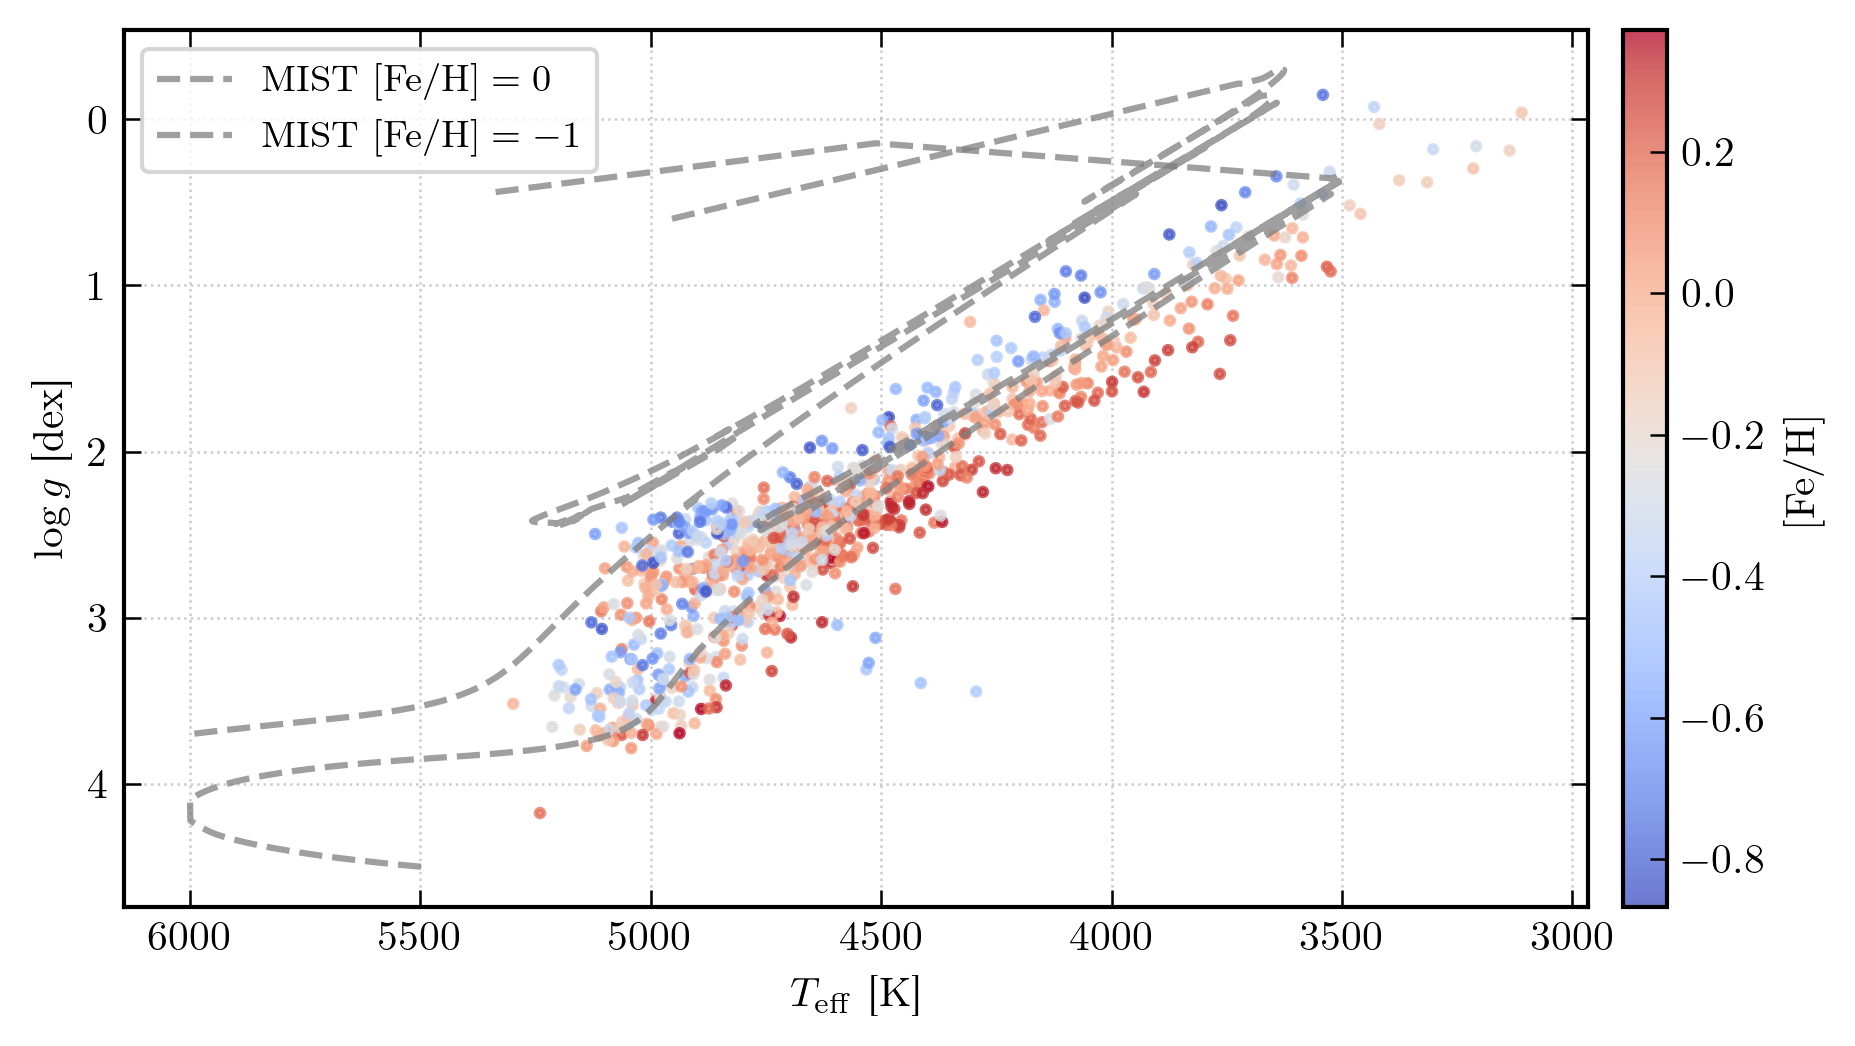

In [18]:
isochrone_tracks = [
    (r"MIST $[\mathrm{Fe/H}]=0$", iso_solar),
    (r"MIST $[\mathrm{Fe/H}]=-1$", iso_metal_poor),
]

ax = plotters.plot_kiel_diagram(fitted_labels, isochrone_tracks)
plotters.savefig(ax.figure, "fig_kiel_diagram.pdf")
plt.show()

### Save cross-validation results

In [19]:
# Save CV results from the original model.
# NB 02's cannon_model.npz is authoritative and is NOT overwritten.
np.savez_compressed(
    "cv_results.npz",
    fitted_labels=fitted_labels,
    true_labels=labels_cv,
    apogee_ids_cv=ids_cv,
)
print("Saved cv_results.npz (original model)")
print(f"  fitted_labels: {fitted_labels.shape}")
print(f"  true_labels: {labels_cv.shape}")


Saved cv_results.npz (original model)
  fitted_labels: (944, 5)
  true_labels: (944, 5)
